# Low-Rank Laplace Approximation: Posterior Predictive Sampling

This notebook demonstrates:
1. Training a small neural network
2. Computing low-rank GGN (Generalized Gauss-Newton)
3. Constructing covariance and scale operators
4. Sampling from the posterior using $\Sigma^{1/2}v$ where $v \sim \mathcal{N}(0, I)$
5. Computing predictive distributions via linearized JVP
6. Averaging softmax predictions for Bayesian model averaging

## Mathematical Background

**Laplace Approximation:**
$$p(\theta | \mathcal{D}) \approx \mathcal{N}(\theta^*, \Sigma)$$
where $\Sigma = (G + \lambda I)^{-1}$ and $G = J^\top H J$ (GGN matrix).

**Low-Rank Approximation:**
$$G \approx Q \Lambda Q^\top$$
$$\Sigma \approx \alpha I + Q \text{diag}(\mu) Q^\top$$
$$\Sigma^{1/2} \approx \beta I + Q \text{diag}(\nu) Q^\top$$

**Posterior Sampling:**
$$\theta \sim \mathcal{N}(\theta^*, \Sigma) \implies \theta = \theta^* + \Sigma^{1/2} v, \quad v \sim \mathcal{N}(0, I)$$

**Linearized Prediction:**
$$f(x, \theta) \approx f(x, \theta^*) + J_\theta f(x, \theta^*) (\theta - \theta^*)$$
$$f(x, \theta^* + \Sigma^{1/2} v) \approx f(x, \theta^*) + J_x \Sigma^{1/2} v$$

We use `torch.func.jvp` to compute $J_x \Sigma^{1/2} v$ efficiently.

## Setup and Imports

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import stats
from scipy.stats import gaussian_kde
from tueplots import bundles


# Disable torch.compile for notebook
import torch._dynamo
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from bul.utils.flatten import (
    flatten_param_dict,
    get_param_keys,
    unflatten_to_param_dict_like,
)
from bul.utils.linear_operators import make_forward_fn

# Import bul utilities
from bul.utils.low_rank import (
    compute_low_rank_eigendecomposition,
    create_ggn_linear_operator,
    get_low_rank_cov_op,
    get_low_rank_ggn_op,
    get_low_rank_scale_op,
)

from untangle.utils import auroc

torch._dynamo.config.disable = True
plt.rcParams.update(bundles.neurips2024(nrows=1, ncols=1))


# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Create a Simple Dataset and Model

We'll use a simple 2D classification problem (two moons) and a small MLP.

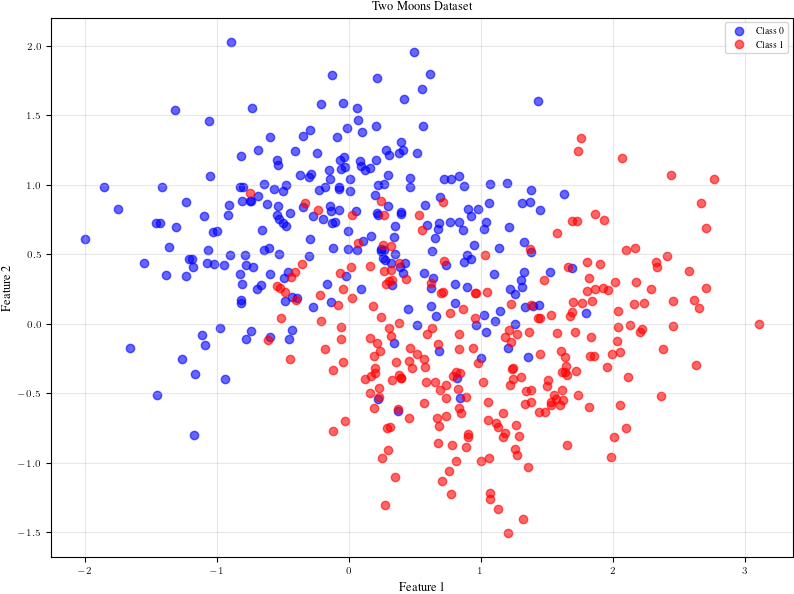

Dataset size: 500
Input dimension: 2
Number of classes: 2


In [49]:
# Generate two moons dataset
from sklearn.datasets import make_moons

n_train_samples = 500
X, y = make_moons(n_samples=n_train_samples, noise=0.4, random_state=42)

# Convert to torch tensors
X_train = torch.tensor(X, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
full_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)

# Visualize dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Two Moons Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("nb_two_moons_dataset.pdf")
plt.show()

print(f"Dataset size: {len(X_train)}")
print(f"Input dimension: {X_train.shape[1]}")
print(f"Number of classes: {len(torch.unique(y_train))}")

In [50]:
# Define a simple MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=20, output_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = SimpleMLP(input_dim=2, hidden_dim=20, output_dim=2).to(device)
print(model)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params}")

SimpleMLP(
  (fc1): Linear(in_features=2, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=2, bias=True)
)

Total parameters: 522


## 2. Train the Model

Train to convergence to get $\theta^*$ (MAP estimate).

Training:   0%|          | 0/50 [00:00<?, ?it/s]

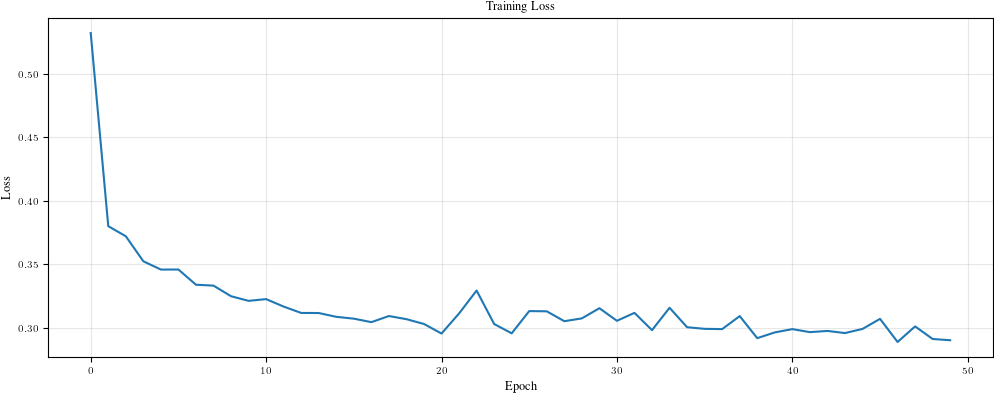


Training accuracy: 86.00%


In [51]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
n_epochs = 50

# Training loop
losses = []
for _epoch in tqdm(range(n_epochs), desc="Training"):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss / len(train_loader))

# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate accuracy
model.eval()
with torch.no_grad():
    outputs = model(X_train.to(device))
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_train.to(device)).float().mean().item()
print(f"\nTraining accuracy: {accuracy * 100:.2f}%")

## 3. Create Low-Rank GGN

Compute $G \approx Q \Lambda Q^\top$ where $G = J^\top H J$.

In [52]:
# Set model to eval mode for linearization
model.eval()

# Create GGN linear operator
print("Creating GGN linear operator...")
G = create_ggn_linear_operator(
    model=model,
    loss="ce",  # cross-entropy loss
    reduction="sum",
    loader=full_loader,
)

print(f"GGN operator shape: {G.shape}")
print(f"GGN operator dtype: {G.dtype}")

# Test matrix-vector product
v = torch.randn(n_params, device=device, dtype=torch.float32)
Gv = G @ v
print(f"\nTest: v shape = {v.shape}, Gv shape = {Gv.shape}")

Creating GGN linear operator...
GGN operator shape: (522, 522)
GGN operator dtype: torch.float32


GGNLinearOperator (cuda:0): 100%|██████████| 1/1 [00:00<00:00, 134.93it/s]


Test: v shape = torch.Size([522]), Gv shape = torch.Size([522])



Computing top-30 eigendecomposition...


GGNLinearOperator (cuda:0): 100%|██████████| 1/1 [00:00<00:00, 186.31it/s]


Eigenvalues shape: torch.Size([30])
Eigenvectors shape: torch.Size([522, 30])

Top 10 eigenvalues: [0.6879603 0.7245874 0.8471436 1.1850501 1.2226022 1.4540377 1.5651861
 1.7044154 1.9927365 2.6198444]


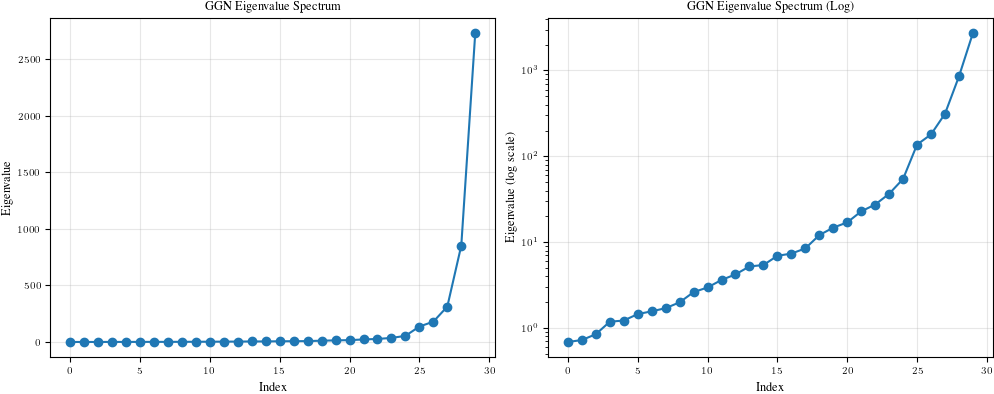

In [53]:
# Compute low-rank eigendecomposition
rank = 30  # Number of top eigenvalues to compute
print(f"\nComputing top-{rank} eigendecomposition...")

eigenvalues, eigenvectors = compute_low_rank_eigendecomposition(
    G,
    rank=rank,
    backend="arpack",
    arpack_kwargs={"curv": {"scipy_dtype": np.float64}},
    skerch_kwargs={},
)

print(f"Eigenvalues shape: {eigenvalues.shape}")
print(f"Eigenvectors shape: {eigenvectors.shape}")
print(f"\nTop 10 eigenvalues: {eigenvalues[:10].cpu().numpy()}")

# Visualize eigenvalue spectrum
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(eigenvalues.cpu().numpy(), 'o-')
plt.xlabel('Index')
plt.ylabel('Eigenvalue')
plt.title('GGN Eigenvalue Spectrum')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogy(eigenvalues.cpu().numpy(), 'o-')
plt.xlabel('Index')
plt.ylabel('Eigenvalue (log scale)')
plt.title('GGN Eigenvalue Spectrum (Log)')
plt.grid(True, alpha=0.3)
plt.savefig("nb_eigenvalue_spectrum.pdf")
plt.show()

## 4. Construct Covariance and Scale Operators

Build $\Sigma = (G + \lambda I)^{-1}$ and $\Sigma^{1/2}$ using low-rank approximations.

In [54]:
# Set prior precision (regularization)
prior_precision = 80.0
print(f"Prior precision (tau): {prior_precision}")

# Get low-rank GGN operator (for verification)
low_rank_ggn_op = get_low_rank_ggn_op(eigenvalues, eigenvectors)

# Get covariance operator: Sigma = (G + tau*I)^{-1}
low_rank_cov_op = get_low_rank_cov_op(eigenvalues, eigenvectors, prior_precision)

# Get scale operator: Sigma^{1/2}
low_rank_scale_op = get_low_rank_scale_op(eigenvalues, eigenvectors, prior_precision)

Prior precision (tau): 80.0


In [55]:
# Verify operators
v_test = torch.randn(n_params, device=device, dtype=torch.float32)

# Test GGN operator
ggn_v = low_rank_ggn_op @ v_test
print(f"GGN @ v: shape = {ggn_v.shape}, norm = {torch.norm(ggn_v).item():.4f}")

# Test covariance operator
cov_v = low_rank_cov_op @ v_test
print(f"Sigma @ v: shape = {cov_v.shape}, norm = {torch.norm(cov_v).item():.4f}")

# Test scale operator
scale_v = low_rank_scale_op @ v_test
scale_norm = torch.norm(scale_v).item()
print(f"Sigma^{{1/2}} @ v: shape = {scale_v.shape}, norm = {scale_norm:.4f}")

# Verify: Sigma^{1/2} @ Sigma^{1/2} ~= Sigma
scale_scale_v = low_rank_scale_op @ scale_v
error = torch.norm(scale_scale_v - cov_v) / torch.norm(cov_v)
rel_error = error.item()
print(
    f"\nRelative error ||Sigma^{{1/2}} @ Sigma^{{1/2}} @ v - Sigma @ v|| / "
    f"||Sigma @ v||: {rel_error:.6f}"
)

GGN @ v: shape = torch.Size([522]), norm = 1079.8373
Sigma @ v: shape = torch.Size([522]), norm = 0.2804
Sigma^{1/2} @ v: shape = torch.Size([522]), norm = 2.5128

Relative error ||Sigma^{1/2} @ Sigma^{1/2} @ v - Sigma @ v|| / ||Sigma @ v||: 0.000000


## 5. Sample from Posterior

Sample $\theta \sim \mathcal{N}(\theta^*, \Sigma)$ using $\theta = \theta^* + \Sigma^{1/2} v$ where $v \sim \mathcal{N}(0, I)$.

In [56]:
# Number of posterior samples
n_posterior_samples = 100

# Get MAP parameters (theta*) using repo flatten utilities
params_dict = dict(model.named_parameters())
param_keys = list(params_dict.keys())
theta_map = flatten_param_dict(params_dict, param_keys)
map_norm = torch.norm(theta_map).item()
print(f"MAP parameters: shape = {theta_map.shape}, norm = {map_norm:.4f}")

# Sample standard normals: v ~ N(0, I)
v_samples = torch.randn(n_params, n_posterior_samples, device=device, dtype=torch.float32)
print(f"\nStandard normal samples: shape = {v_samples.shape}")

# Transform to posterior samples: Sigma^{1/2} @ v
print("Transforming to posterior samples...")
perturbations = low_rank_scale_op @ v_samples  # [P, n_posterior_samples]
print(f"Perturbations: shape = {perturbations.shape}")

# Posterior samples: theta = theta* + Sigma^{1/2} @ v
theta_samples = theta_map.unsqueeze(1) + perturbations  # [P, n_posterior_samples]
print(f"Posterior samples: shape = {theta_samples.shape}")

# Analyze samples
sample_norms = torch.norm(perturbations, dim=0)
mean_norm = sample_norms.mean().item()
std_norm = sample_norms.std().item()
min_norm = sample_norms.min().item()
max_norm = sample_norms.max().item()
print(f"\nPerturbation norms: mean = {mean_norm:.4f}, std = {std_norm:.4f}")
print(f"Perturbation norms: min = {min_norm:.4f}, max = {max_norm:.4f}")

MAP parameters: shape = torch.Size([522]), norm = 9.8048

Standard normal samples: shape = torch.Size([522, 100])
Transforming to posterior samples...
Perturbations: shape = torch.Size([522, 100])
Posterior samples: shape = torch.Size([522, 100])

Perturbation norms: mean = 2.5363, std = 0.0748
Perturbation norms: min = 2.2948, max = 2.7167


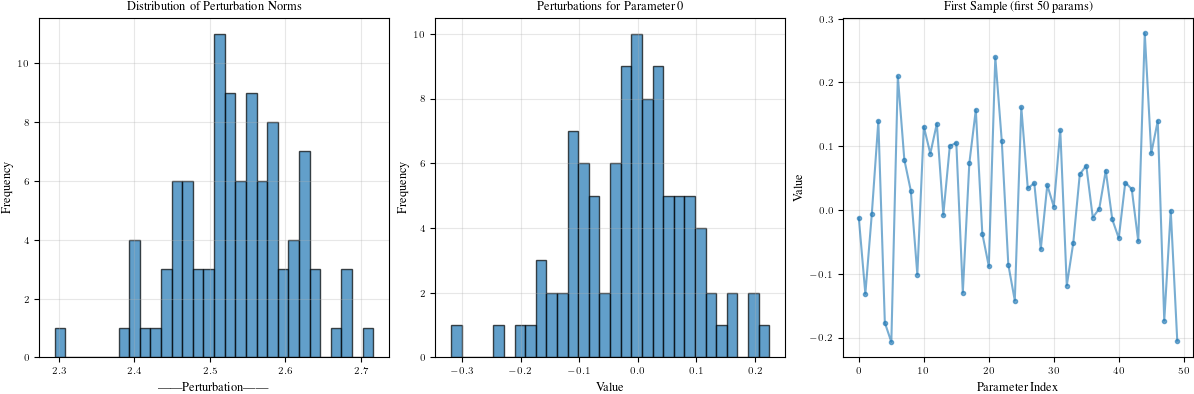

In [57]:
# Visualize perturbation distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(sample_norms.cpu().numpy(), bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('||Perturbation||')
plt.ylabel('Frequency')
plt.title('Distribution of Perturbation Norms')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
first_param_samples = perturbations[0, :].cpu().numpy()
plt.hist(first_param_samples, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Perturbations for Parameter 0')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(perturbations[:50, 0].cpu().numpy(), 'o-', alpha=0.6, markersize=3)
plt.xlabel('Parameter Index')
plt.ylabel('Value')
plt.title('First Sample (first 50 params)')
plt.grid(True, alpha=0.3)

plt.savefig("nb_perturbations_lessNoise.pdf")
plt.show()

## 6. Linearized Prediction with JVP

Compute $f(x, \theta) \approx f(x, \theta^*) + J_x \Sigma^{1/2} v$ using `torch.func.jvp`.

In [58]:
# Store parameters for JVP
params_dict = dict(model.named_parameters())
param_keys = list(params_dict.keys())
print(f"Model parameters: {len(params_dict)} tensors")
print(f"Parameter names: {param_keys}")

Model parameters: 6 tensors
Parameter names: ['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias']


In [59]:
# Prepare test inputs (use a grid for visualization)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))
X_test = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32, device=device)

print(f"Test grid: {X_test.shape}")

Test grid: torch.Size([2500, 2])


In [60]:
# Compute base prediction: f(x, theta*)
with torch.no_grad():
    base_logits = model(X_test)  # [N, C]

print(f"Base logits: shape = {base_logits.shape}")
min_logit = base_logits.min().item()
max_logit = base_logits.max().item()
print(f"Base logits: min = {min_logit:.4f}, max = {max_logit:.4f}")

Base logits: shape = torch.Size([2500, 2])
Base logits: min = -9.2160, max = 12.4413


In [61]:
# Compute JVP for multiple samples
# We need to compute: J_x @ (Sigma^{1/2} @ v) for each sample
# This is done by: jvp(f, (theta*,), (Sigma^{1/2} @ v,))

from torch.func import jvp


def compute_jvp_single(model, params_dict, param_keys, inputs, tangent_flat):
    """Compute JVP for a single tangent vector.

    Args:
        model: The neural network
        params_dict: Dictionary of model parameters
        param_keys: List of parameter names
        inputs: Input tensor [N, input_dim]
        tangent_flat: Flattened tangent vector [P]

    Returns:
        JVP result [N, output_dim]
    """
    # Unflatten tangent using repo utility
    tangent_dict = unflatten_to_param_dict_like(tangent_flat, params_dict, param_keys)

    # Use repo's make_forward_fn
    forward_fn = make_forward_fn(
        original_model=model,
        buffers=dict(model.named_buffers()),
        inputs=inputs,
    )

    # Compute JVP
    _, jvp_output = jvp(forward_fn, (params_dict,), (tangent_dict,))
    return jvp_output


print("Computing JVP for all samples...")

# Compute JVP for each sample
n_samples_predict = n_posterior_samples
jvp_results = []

for i in tqdm(range(n_samples_predict), desc="Computing JVPs"):
    tangent = perturbations[:, i]  # [P]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_test, tangent)
    jvp_results.append(jvp_output)

# Stack results: [n_samples, N, C]
jvp_results = torch.stack(jvp_results, dim=0)
print(f"\nJVP results: shape = {jvp_results.shape}")

Computing JVP for all samples...


Computing JVPs:   0%|          | 0/100 [00:00<?, ?it/s]


JVP results: shape = torch.Size([100, 2500, 2])


## 7. Compute Predictive Distribution

For each sample:
1. Compute logits: $f(x, \theta^*) + J_x \Sigma^{1/2} v$
2. Apply softmax to get probabilities
3. Average probabilities across samples

In [62]:
# Compute sampled logits: f(x, theta*) + J_x Sigma^{1/2} v
sampled_logits = base_logits.unsqueeze(0) + jvp_results  # [n_samples, N, C]
print(f"Sampled logits: shape = {sampled_logits.shape}")

# Apply softmax to each sample
sampled_probs = F.softmax(sampled_logits, dim=-1)  # [n_samples, N, C]
print(f"Sampled probabilities: shape = {sampled_probs.shape}")

# Average probabilities (Bayesian Model Averaging) and detach
predictive_probs = sampled_probs.mean(dim=0).detach()  # [N, C]
print(f"Predictive probabilities: shape = {predictive_probs.shape}")

# Compute predictive entropy (uncertainty)
log_probs = torch.log(predictive_probs + 1e-10)
predictive_entropy = -torch.sum(predictive_probs * log_probs, dim=-1)
print(f"Predictive entropy: shape = {predictive_entropy.shape}")
mean_entropy = predictive_entropy.mean().item()
max_entropy = predictive_entropy.max().item()
print(f"Predictive entropy: mean = {mean_entropy:.4f}, max = {max_entropy:.4f}")

Sampled logits: shape = torch.Size([100, 2500, 2])
Sampled probabilities: shape = torch.Size([100, 2500, 2])
Predictive probabilities: shape = torch.Size([2500, 2])
Predictive entropy: shape = torch.Size([2500])
Predictive entropy: mean = 0.1383, max = 0.6931


In [63]:
# Compare with MAP prediction
with torch.no_grad():
    map_probs = F.softmax(model(X_test), dim=-1).detach()

print(f"\nMAP probabilities: shape = {map_probs.shape}")
diff_norm = torch.norm(predictive_probs - map_probs).item()
print(f"Difference ||p_predictive - p_MAP||: {diff_norm:.4f}")


MAP probabilities: shape = torch.Size([2500, 2])
Difference ||p_predictive - p_MAP||: 1.2719


## 8. Visualization

Visualize decision boundaries and uncertainty.

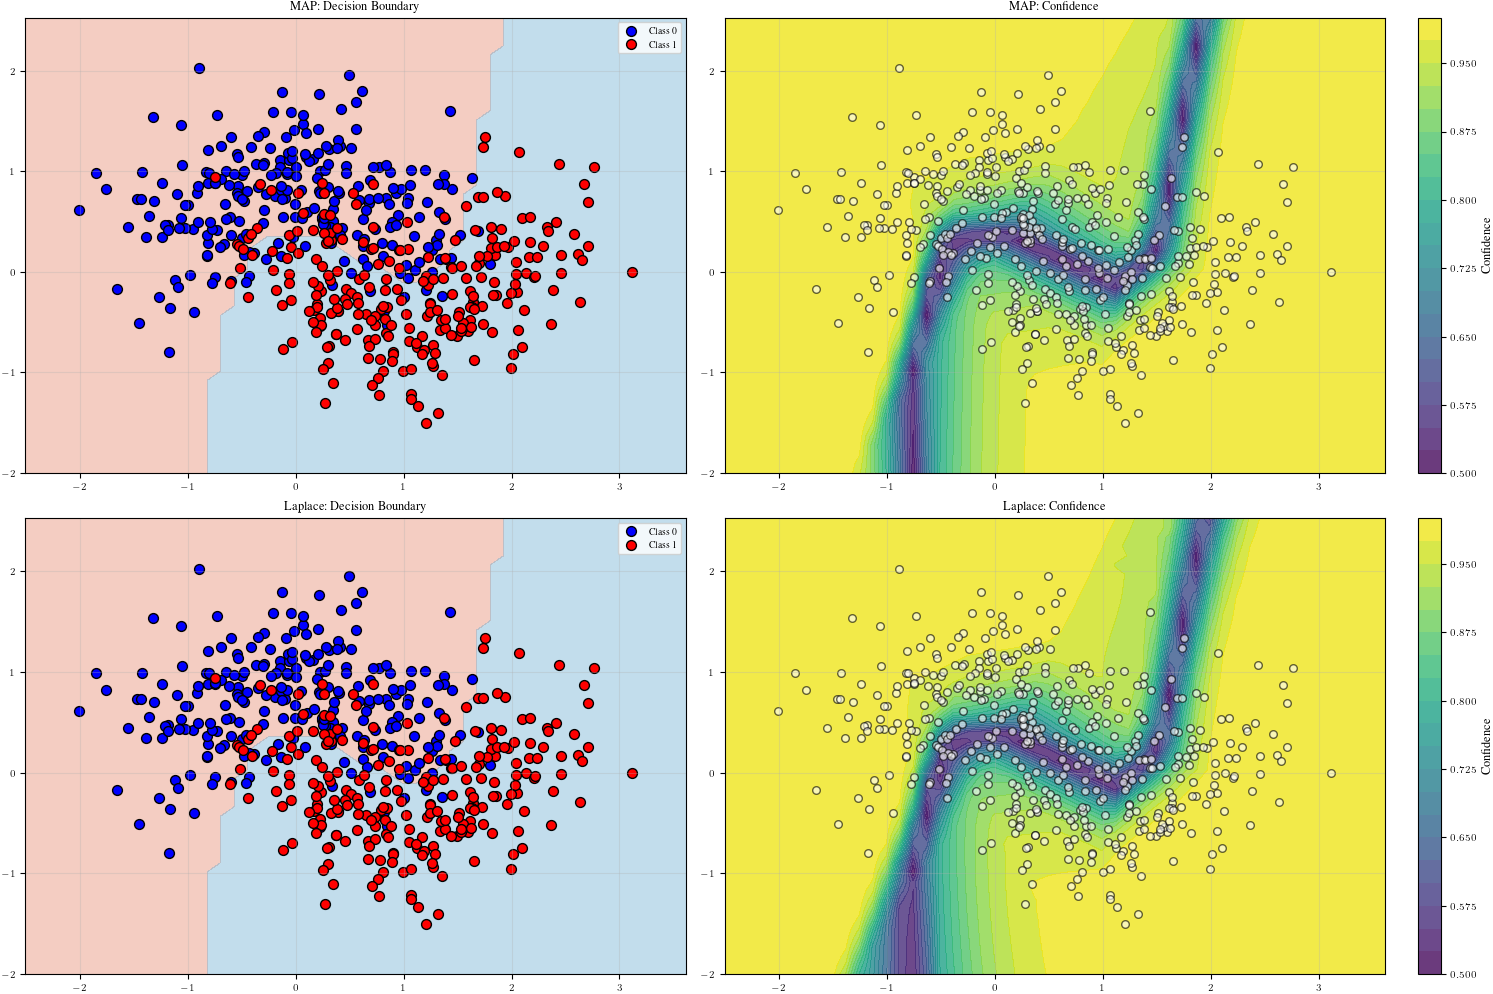

In [64]:
# Prepare data for plotting
predictive_class = predictive_probs.argmax(dim=-1).cpu().numpy().reshape(xx.shape)
predictive_confidence = predictive_probs.max(dim=-1)[0].cpu().numpy().reshape(xx.shape)
predictive_entropy_2d = predictive_entropy.cpu().numpy().reshape(xx.shape)

map_class = map_probs.argmax(dim=-1).cpu().numpy().reshape(xx.shape)
map_confidence = map_probs.max(dim=-1)[0].cpu().numpy().reshape(xx.shape)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Row 1: MAP predictions
axes[0, 0].contourf(xx, yy, map_class, alpha=0.4, levels=1, cmap='RdBu')
axes[0, 0].scatter(
    X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', edgecolors='k', s=50
)
axes[0, 0].scatter(
    X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', edgecolors='k', s=50
)
axes[0, 0].set_title('MAP: Decision Boundary')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

cf1 = axes[0, 1].contourf(xx, yy, map_confidence, alpha=0.8, levels=20, cmap='viridis')
axes[0, 1].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axes[0, 1].set_title('MAP: Confidence')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(cf1, ax=axes[0, 1], label="Confidence")


# Row 2: Laplace predictions
axes[1, 0].contourf(xx, yy, predictive_class, alpha=0.4, levels=1, cmap='RdBu')
axes[1, 0].scatter(
    X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', edgecolors='k', s=50
)
axes[1, 0].scatter(
    X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', edgecolors='k', s=50
)
axes[1, 0].set_title('Laplace: Decision Boundary')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

cf2 = axes[1, 1].contourf(
    xx, yy, predictive_confidence, alpha=0.8, levels=20, cmap='viridis'
)
axes[1, 1].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axes[1, 1].set_title('Laplace: Confidence')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(cf2, ax=axes[1, 1], label="Confidence")

#plt.tight_layout()
plt.savefig("nb_map_vs_laplace.pdf")
plt.show()

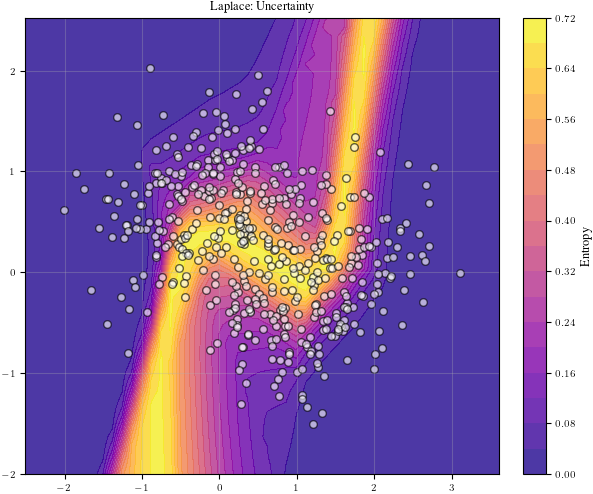

In [65]:

plt.figure(figsize=(6, 5))
cf = plt.contourf(
    xx, yy, predictive_entropy_2d, alpha=0.8, levels=20, cmap='plasma'
)
plt.scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
plt.title('Laplace: Uncertainty')
plt.grid(True, alpha=0.3)
plt.colorbar(cf, label="Entropy")
plt.savefig("nb_laplace_entropy.pdf")
plt.show()

## 9. Aleatoric & Epistemic Uncertainty

Aleatoric: average entropy across samples 

Epistemic: Diff between total predictive uncertainty and aleatoric $\rightarrow$ disagreement between posterior samples

In [66]:
# Total predictive probability and uncertainty (entropy)
# predictive_probs = sampled_probs.mean(dim=0)  
# log_probs = torch.log(predictive_probs + 1e-10)
# predictive_entropy = -torch.sum(predictive_probs * log_probs, dim=-1)  

# -> total predictive entropy for each sample point

In [67]:
# compute entropy for every sampled prob and then average 
# -> aleatoric uncertainty
sampled_log_probs = torch.log(sampled_probs + 1e-10)
aleatoric_entropy = -torch.sum(sampled_probs * sampled_log_probs, dim=-1)
mean_aleatoric_entropy = aleatoric_entropy.mean(dim=0)  # [N]
print(f"Aleatoric entropy: shape = {mean_aleatoric_entropy.shape}")

Aleatoric entropy: shape = torch.Size([2500])


In [68]:
# epistemic uncertainty
epistemic_entropy = predictive_entropy - mean_aleatoric_entropy
print(f"Epistemic entropy: shape = {epistemic_entropy.shape}") 


Epistemic entropy: shape = torch.Size([2500])


### Visualization

Spearman correlation: 0.961, p-value: 0.000e+00


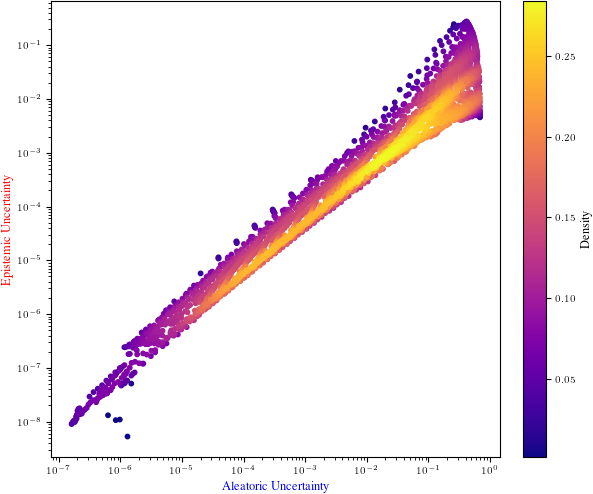

In [69]:
# Plot correlation aleatoric vs epistemic uncertainty
ax1_aleatoric = mean_aleatoric_entropy.detach().cpu().numpy()
ax2_epistemic = epistemic_entropy.detach().cpu().numpy()

correlation, p_value = stats.spearmanr(ax1_aleatoric, ax2_epistemic)

print(f"Spearman correlation: {correlation:.3f}, p-value: {p_value:.3e}") 

# Filter out zero or negative values for log-log plot
mask = (ax1_aleatoric > 0) & (ax2_epistemic > 0)
ax1_aleatoric, ax2_epistemic = ax1_aleatoric[mask], ax2_epistemic[mask]

# Density estimation (for color)
xy = np.vstack([np.log10(ax1_aleatoric), np.log10(ax2_epistemic)])
z = gaussian_kde(xy)(xy)

# Sort by density (so dense points are on top)
idx = z.argsort()
ax1_aleatoric, ax2_epistemic, z = ax1_aleatoric[idx], ax2_epistemic[idx], z[idx]

plt.figure(figsize=(6, 5))
cf = plt.scatter(ax1_aleatoric, ax2_epistemic, c=z, s=10, cmap="plasma")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Aleatoric Uncertainty", color="blue")
plt.ylabel("Epistemic Uncertainty", color="red")

plt.colorbar(cf, label="Density")
plt.savefig("nb_correlation_sameSet.pdf")
plt.show()


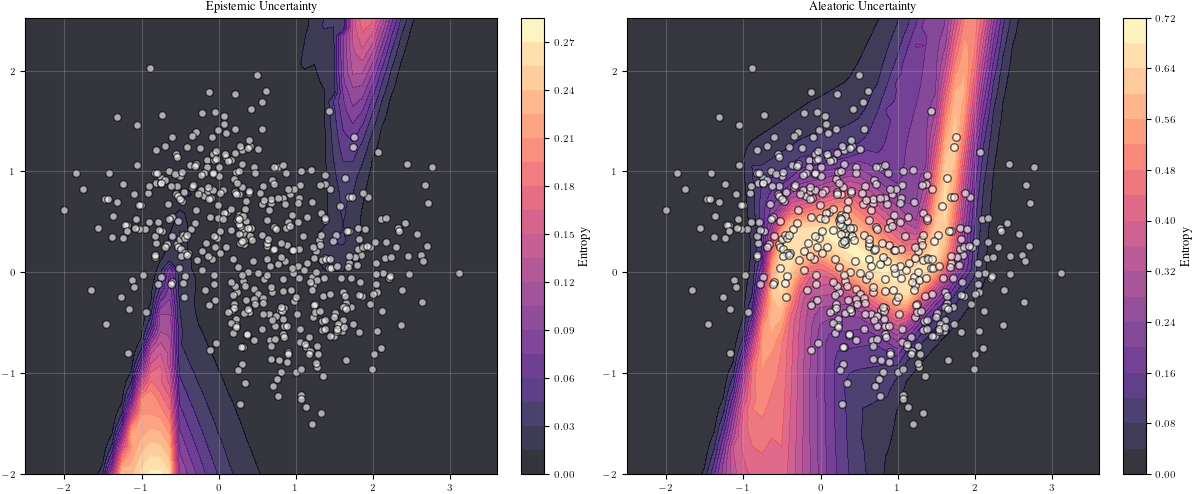

In [70]:
# Prepare data for plotting
mean_aleatoric_entropy_2d = mean_aleatoric_entropy.detach().cpu().numpy().reshape(xx.shape)
epistemic_entropy_2d = epistemic_entropy.detach().cpu().numpy().reshape(xx.shape)

fig, axs = plt.subplots(1, 2, figsize=(12,5))

cf1 = axs[0].contourf(
    xx, yy, epistemic_entropy_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[0].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[0].set_title('Epistemic Uncertainty')
axs[0].grid(True, alpha=0.3)
plt.colorbar(cf1, ax=axs[0], label="Entropy")

cf2 = axs[1].contourf(
    xx, yy, mean_aleatoric_entropy_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[1].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1].set_title('Aleatoric Uncertainty')
axs[1].grid(True, alpha=0.3)
plt.colorbar(cf2, ax=axs[1], label="Entropy")



plt.savefig("nb_aleatoric_epistemic_sameSet.pdf")
plt.show()

AU: 
- high, when all models are uncertain $\longrightarrow$ noisy in the middle
- low, when all models are certain $\longrightarrow$ region with no data points

EU:  
- high, when $y$ depends a lot on $\theta$, all models predict diff things $\longrightarrow$ region where MAP and laplace also uncertain
- low, when all models predict the same thing $\longrightarrow$ regions where decision boundaries are clear

1. All models are uncertain $\Longrightarrow$ AU maximal, EU = 0
2. All models predict the same thing and are very certain $\Longrightarrow$ AU=0, EU=0 , PU=0
3. All models predict different things and are very certain $\Longrightarrow$ AU=0, EU max
4. All models predict different things and are very uncertain $\Longrightarrow$ impossible

## 11. Two seperate Laplace Approximations
Create two subsets of $\theta$
- (epistemic): first layer (fc1.weight, fc1.bias) 
- (aleatoric): output layer (fc3.weight, fc3.bias)
- Sampling with two Laplace posteriors


In [71]:
# Compute start/end indices
shapes = [params_dict[name].numel() for name in param_keys] 
starts, ends = [], []
offset = 0
for n in shapes:
    starts.append(offset)
    ends.append(offset + n)
    offset += n
P = offset

# Define subsets
subset_first_layer = ['fc1.weight', 'fc1.bias']
subset_last_layer = ['fc3.weight', 'fc3.bias']

# Build boolean masks
s1_mask = torch.zeros(P, dtype=torch.bool)
s2_mask = torch.zeros(P, dtype=torch.bool)

for i, name in enumerate(param_keys):
    if name in subset_first_layer:
        s1_mask[starts[i]:ends[i]] = True
    elif name in subset_last_layer:
        s2_mask[starts[i]:ends[i]] = True

# check if the two masks are disjoint
assert not (s1_mask & s2_mask).any()

print(f's1 mask Sum: {s1_mask.sum()}')
print(f's2 mask Sum: {s2_mask.sum()}')

s1 mask Sum: 60
s2 mask Sum: 42


## 1. First-Layer - Laplace (epistemic)

In [72]:
model.eval()

# Temporarily set requires_grad
for name, param in model.named_parameters():
    if name not in subset_first_layer:
        param.requires_grad = False

n_params_s1 = sum(p.numel() for p in model.parameters()if p.requires_grad)

print("Creating epistemic GGN...")
G_s1 = create_ggn_linear_operator(
    model=model,
    loss="ce",
    reduction="sum",
    loader=full_loader,
)
print(f"GGN operator shape: {G_s1.shape}")
print(f"GGN operator dtype: {G_s1.dtype}")

# Test matrix-vector product
v = torch.randn(n_params_s1, device=device, dtype=torch.float32)
Gv_s1 = G_s1 @ v
print(f"\nTest: v shape = {v.shape}, Gv shape = {Gv_s1.shape}")

# Compute low-rank eigendecomposition
print(f"\nComputing top-{rank} eigendecomposition...")

s1_eigenvalues, s1_eigenvectors = compute_low_rank_eigendecomposition(
    G_s1,
    rank=rank,
    backend="arpack",
    arpack_kwargs={"curv": {"scipy_dtype": np.float64}},
    skerch_kwargs={},
)

print(f"Eigenvalues shape: {s1_eigenvalues.shape}")
print(f"Eigenvectors shape: {s1_eigenvectors.shape}")
print(f"\nTop 10 eigenvalues: {s1_eigenvalues[:10].cpu().numpy()}")

# Get low-rank GGN operator (for verification)
low_rank_ggn_op_s1 = get_low_rank_ggn_op(s1_eigenvalues, s1_eigenvectors)
# Get covariance operator: Sigma = (G + tau*I)^{-1}
low_rank_cov_op_s1 = get_low_rank_cov_op(s1_eigenvalues, s1_eigenvectors, prior_precision)

# Get scale operator: Sigma^{1/2}
low_rank_scale_op_s1 = get_low_rank_scale_op(s1_eigenvalues, s1_eigenvectors, prior_precision)

# Verify operators
v_test_s1 = torch.randn(n_params_s1, device=device, dtype=torch.float32)

# Test GGN operator
ggn_v_s1 = low_rank_ggn_op_s1 @ v_test_s1
print(f"GGN @ v: shape = {ggn_v_s1.shape}, norm = {torch.norm(ggn_v_s1).item():.4f}")

# Test covariance operator
cov_v_s1 = low_rank_cov_op_s1 @ v_test_s1
print(f"Sigma @ v: shape = {cov_v_s1.shape}, norm = {torch.norm(cov_v_s1).item():.4f}")

# Test scale operator
scale_v_s1 = low_rank_scale_op_s1 @ v_test_s1
scale_norm_s1 = torch.norm(scale_v_s1).item()
print(f"Sigma^{{1/2}} @ v: shape = {scale_v_s1.shape}, norm = {scale_norm_s1:.4f}")

# Verify: Sigma^{1/2} @ Sigma^{1/2} ~= Sigma
scale_scale_v_s1 = low_rank_scale_op_s1 @ scale_v_s1
error_s1 = torch.norm(scale_scale_v_s1 - cov_v_s1) / torch.norm(cov_v_s1)
rel_error_s1 = error_s1.item()
print(
    f"\nRelative error ||Sigma^{{1/2}} @ Sigma^{{1/2}} @ v - Sigma @ v|| / "
    f"||Sigma @ v||: {rel_error_s1:.6f}"
)

Creating epistemic GGN...
GGN operator shape: (60, 60)
GGN operator dtype: torch.float32


GGNLinearOperator (cuda:0): 100%|██████████| 1/1 [00:00<00:00, 179.04it/s]



Test: v shape = torch.Size([60]), Gv shape = torch.Size([60])

Computing top-30 eigendecomposition...


GGNLinearOperator (cuda:0): 100%|██████████| 1/1 [00:00<00:00, 182.09it/s]

Eigenvalues shape: torch.Size([30])
Eigenvectors shape: torch.Size([60, 30])

Top 10 eigenvalues: [0.29647025 0.35002747 0.37846324 0.43279678 0.43946823 0.48307577
 0.64580345 0.72754294 0.84249955 0.8970703 ]
GGN @ v: shape = torch.Size([60]), norm = 2029.4579
Sigma @ v: shape = torch.Size([60]), norm = 0.0903
Sigma^{1/2} @ v: shape = torch.Size([60]), norm = 0.8290

Relative error ||Sigma^{1/2} @ Sigma^{1/2} @ v - Sigma @ v|| / ||Sigma @ v||: 0.000000


In [73]:
theta_s1 = flatten_param_dict(params_dict, subset_first_layer)

# Sample standard normals: v ~ N(0, I)
v_samples_s1 = torch.randn(n_params_s1, n_posterior_samples, device=device, dtype=torch.float32)
print(f"\nStandard normal samples: shape = {v_samples_s1.shape}")

# Transform to posterior samples: Sigma^{1/2} @ v
print("Transforming to posterior samples...")
perturbations_s1 = low_rank_scale_op_s1 @ v_samples_s1  # [P, n_posterior_samples]
print(f"Perturbations: shape = {perturbations_s1.shape}")

# Posterior samples: theta = theta_s1 + Sigma^{1/2} @ v
theta_samples_s1 = theta_s1.unsqueeze(1) + perturbations_s1  # [P, n_posterior_samples]
print(f"Posterior samples: shape = {theta_samples_s1.shape}")

# Analyze samples
sample_norms_s1 = torch.norm(perturbations_s1, dim=0)
mean_norm = sample_norms_s1.mean().item()
std_norm = sample_norms_s1.std().item()
min_norm = sample_norms_s1.min().item()
max_norm = sample_norms_s1.max().item()
print(f"\nPerturbation norms: mean = {mean_norm:.4f}, std = {std_norm:.4f}")
print(f"Perturbation norms: min = {min_norm:.4f}, max = {max_norm:.4f}")


Standard normal samples: shape = torch.Size([60, 100])
Transforming to posterior samples...
Perturbations: shape = torch.Size([60, 100])
Posterior samples: shape = torch.Size([60, 100])

Perturbation norms: mean = 0.8192, std = 0.0818
Perturbation norms: min = 0.6110, max = 1.0851


In [74]:
perturbations_s1_full = torch.zeros(P, n_posterior_samples, device=device)
perturbations_s1_full[s1_mask, :] = perturbations_s1

print(f"shape {perturbations_s1_full.shape}")

shape torch.Size([522, 100])


In [75]:
print("Computing JVP for all subset 1 samples...")

# Compute JVP for each sample
#n_samples_predict = 100
jvp_results_s1 = []

for i in tqdm(range(n_samples_predict), desc="Computing JVPs"):
    tangent = perturbations_s1_full[:, i]  # [P]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_test, tangent)
    jvp_results_s1.append(jvp_output)

# Stack results: [n_samples, N, C]
jvp_results_s1 = torch.stack(jvp_results_s1, dim=0)
print(f"\nJVP results: shape = {jvp_results_s1.shape}")
# Compute sampled logits: f(x, theta) + J_x Sigma^{1/2} v
sampled_logits_s1 = base_logits.unsqueeze(0) + jvp_results_s1  # [n_samples, N, C]
print(f"Sampled logits: shape = {sampled_logits_s1.shape}")

# Apply softmax to each sample
sampled_probs_s1 = F.softmax(sampled_logits_s1, dim=-1)  # [n_samples, N, C]
print(f"Sampled probabilities: shape = {sampled_probs_s1.shape}")

# Average probabilities (Bayesian Model Averaging) and detach
predictive_probs_s1 = sampled_probs_s1.mean(dim=0).detach()  # [N, C]
print(f"Predictive probabilities: shape = {predictive_probs_s1.shape}")
# Compute predictive entropy (uncertainty)
log_probs_s1 = torch.log(predictive_probs_s1 + 1e-10)
predictive_entropy_s1 = -torch.sum(predictive_probs_s1 * log_probs_s1, dim=-1)
print(f"Predictive entropy subset 1: shape = {predictive_entropy_s1.shape}")
mean_entropy_s1 = predictive_entropy_s1.mean().item()
max_entropy_s1 = predictive_entropy_s1.max().item()
print(f"Predictive entropy: mean = {mean_entropy_s1:.4f}, max = {max_entropy_s1:.4f}")

# Restore all requires_grad
for param in model.parameters():
    param.requires_grad = True

Computing JVP for all subset 1 samples...


Computing JVPs:   0%|          | 0/100 [00:00<?, ?it/s]


JVP results: shape = torch.Size([100, 2500, 2])
Sampled logits: shape = torch.Size([100, 2500, 2])
Sampled probabilities: shape = torch.Size([100, 2500, 2])
Predictive probabilities: shape = torch.Size([2500, 2])
Predictive entropy subset 1: shape = torch.Size([2500])
Predictive entropy: mean = 0.1378, max = 0.6931


## 2. Aleatoric Laplace 

In [76]:
# Temporarily set requires_grad
for name, param in model.named_parameters():
    if name not in subset_last_layer:
        param.requires_grad = False

n_params_s2 = sum(p.numel() for p in model.parameters()if p.requires_grad)

G_s2 = create_ggn_linear_operator(
    model=model,
    loss="ce",
    reduction="sum",
    loader=full_loader,
)
print(f"GGN operator shape: {G_s2.shape}")
print(f"GGN operator dtype: {G_s2.dtype}")

# Test matrix-vector product
v = torch.randn(n_params_s2, device=device, dtype=torch.float32)
Gv_s2 = G_s2 @ v
print(f"\nTest: v shape = {v.shape}, Gv shape = {Gv_s2.shape}")

# Compute low-rank eigendecomposition
print(f"\nComputing top-{rank} eigendecomposition...")

s2_eigenvalues, s2_eigenvectors = compute_low_rank_eigendecomposition(
    G_s2,
    rank=rank,
    backend="arpack",
    arpack_kwargs={"curv": {"scipy_dtype": np.float64}},
    skerch_kwargs={},
)

print(f"Eigenvalues shape: {s2_eigenvalues.shape}")
print(f"Eigenvectors shape: {s2_eigenvectors.shape}")
print(f"\nTop 10 eigenvalues: {s2_eigenvalues[:10].cpu().numpy()}")

# Get low-rank GGN operator (for verification)
low_rank_ggn_op_s2 = get_low_rank_ggn_op(s2_eigenvalues, s2_eigenvectors)
# Get covariance operator: Sigma = (G + tau*I)^{-1}
low_rank_cov_op_s2 = get_low_rank_cov_op(s2_eigenvalues, s2_eigenvectors, prior_precision)

# Get scale operator: Sigma^{1/2}
low_rank_scale_op_s2 = get_low_rank_scale_op(s2_eigenvalues, s2_eigenvectors, prior_precision)
# Verify operators
v_test = torch.randn(n_params_s2, device=device, dtype=torch.float32)

# Test GGN operator
ggn_v_s2 = low_rank_ggn_op_s2 @ v_test
print(f"GGN @ v: shape = {ggn_v_s2.shape}, norm = {torch.norm(ggn_v_s2).item():.4f}")

# Test covariance operator
cov_v_s2 = low_rank_cov_op_s2 @ v_test
print(f"Sigma @ v: shape = {cov_v_s2.shape}, norm = {torch.norm(cov_v_s2).item():.4f}")

# Test scale operator
scale_v_s2 = low_rank_scale_op_s2 @ v_test
scale_norm_s2 = torch.norm(scale_v_s2).item()
print(f"Sigma^{{1/2}} @ v: shape = {scale_v_s2.shape}, norm = {scale_norm_s2:.4f}")

# Verify: Sigma^{1/2} @ Sigma^{1/2} ~= Sigma
scale_scale_v_s2 = low_rank_scale_op_s2 @ scale_v_s2
error_s2 = torch.norm(scale_scale_v_s2 - cov_v_s2) / torch.norm(cov_v_s2)
rel_error_s2 = error_s2.item()
print(
    f"\nRelative error ||Sigma^{{1/2}} @ Sigma^{{1/2}} @ v - Sigma @ v|| / "
    f"||Sigma @ v||: {rel_error_s2:.6f}"
)

GGN operator shape: (42, 42)
GGN operator dtype: torch.float32


GGNLinearOperator (cuda:0):   0%|          | 0/1 [00:00<?, ?it/s]

GGNLinearOperator (cuda:0): 100%|██████████| 1/1 [00:00<00:00, 102.92it/s]



Test: v shape = torch.Size([42]), Gv shape = torch.Size([42])

Computing top-30 eigendecomposition...


GGNLinearOperator (cuda:0): 100%|██████████| 1/1 [00:00<00:00, 203.63it/s]


Eigenvalues shape: torch.Size([30])
Eigenvectors shape: torch.Size([42, 30])

Top 10 eigenvalues: [-8.1175431e-06 -6.1741724e-07 -3.0797253e-07 -1.7209440e-07
 -1.0501529e-07 -2.3120029e-08 -2.2907711e-09 -2.0546695e-13
 -0.0000000e+00  0.0000000e+00]
GGN @ v: shape = torch.Size([42]), norm = 403.3719
Sigma @ v: shape = torch.Size([42]), norm = 0.0809
Sigma^{1/2} @ v: shape = torch.Size([42]), norm = 0.7378

Relative error ||Sigma^{1/2} @ Sigma^{1/2} @ v - Sigma @ v|| / ||Sigma @ v||: 0.000000


In [77]:
theta_s2 = flatten_param_dict(params_dict, subset_last_layer)

# Sample standard normals: v ~ N(0, I)
v_samples_s2 = torch.randn(n_params_s2, n_posterior_samples, device=device, dtype=torch.float32)
print(f"\nStandard normal samples: shape = {v_samples_s2.shape}")

# Transform to posterior samples: Sigma^{1/2} @ v
print("Transforming to posterior samples...")
perturbations_s2 = low_rank_scale_op_s2 @ v_samples_s2  # [P, n_posterior_samples]
print(f"Perturbations: shape = {perturbations_s2.shape}")

# Posterior samples: theta = theta_s2 + Sigma^{1/2} @ v
theta_samples_s2 = theta_s2.unsqueeze(1) + perturbations_s2  # [P, n_posterior_samples]
print(f"Posterior samples: shape = {theta_samples_s2.shape}")

# Analyze samples
sample_norms_s2 = torch.norm(perturbations_s2, dim=0)
mean_norm = sample_norms_s2.mean().item()
std_norm = sample_norms_s2.std().item()
min_norm = sample_norms_s2.min().item()
max_norm = sample_norms_s2.max().item()
print(f"\nPerturbation norms: mean = {mean_norm:.4f}, std = {std_norm:.4f}")
print(f"Perturbation norms: min = {min_norm:.4f}, max = {max_norm:.4f}")


Standard normal samples: shape = torch.Size([42, 100])
Transforming to posterior samples...
Perturbations: shape = torch.Size([42, 100])
Posterior samples: shape = torch.Size([42, 100])

Perturbation norms: mean = 0.7094, std = 0.0763
Perturbation norms: min = 0.5670, max = 0.9052


In [78]:
perturbations_s2_full = torch.zeros(P, n_posterior_samples, device=device)
perturbations_s2_full[s2_mask, :] = perturbations_s2

print(f"shape {perturbations_s2_full.shape}")

shape torch.Size([522, 100])


In [79]:
print("Computing JVP for all subset 2 samples...")

# Compute JVP for each sample
#n_samples_predict = 100
jvp_results_s2 = []

for i in tqdm(range(n_samples_predict), desc="Computing JVPs"):
    tangent = perturbations_s2_full[:, i]  # [P]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_test, tangent)
    jvp_results_s2.append(jvp_output)

# Stack results: [n_samples, N, C]
jvp_results_s2 = torch.stack(jvp_results_s2, dim=0)
print(f"\nJVP results: shape = {jvp_results_s2.shape}")
# Compute sampled logits: f(x, theta) + J_x Sigma^{1/2} v
sampled_logits_s2 = base_logits.unsqueeze(0) + jvp_results_s2  # [n_samples, N, C]
print(f"Sampled logits: shape = {sampled_logits_s2.shape}")

# Apply softmax to each sample
sampled_probs_s2 = F.softmax(sampled_logits_s2, dim=-1)  # [n_samples, N, C]
print(f"Sampled probabilities: shape = {sampled_probs_s2.shape}")

# Average probabilities (Bayesian Model Averaging) and detach
predictive_probs_s2 = sampled_probs_s2.mean(dim=0).detach()  # [N, C]
print(f"Predictive probabilities: shape = {predictive_probs_s2.shape}")

# Compute predictive entropy (uncertainty)
log_probs_s2 = torch.log(predictive_probs_s2 + 1e-10)
predictive_entropy_s2 = -torch.sum(predictive_probs_s2 * log_probs_s2, dim=-1)
print(f"Predictive entropy last layer: shape = {predictive_entropy_s2.shape}")
mean_entropy_s2 = predictive_entropy_s2.mean().item()
max_entropy_s2 = predictive_entropy_s2.max().item()
print(f"Predictive entropy last layer: mean = {mean_entropy_s2:.4f}, max = {max_entropy_s2:.4f}")
# Restore all requires_grad
for param in model.parameters():
    param.requires_grad = True

Computing JVP for all subset 2 samples...


Computing JVPs:   0%|          | 0/100 [00:00<?, ?it/s]


JVP results: shape = torch.Size([100, 2500, 2])
Sampled logits: shape = torch.Size([100, 2500, 2])
Sampled probabilities: shape = torch.Size([100, 2500, 2])
Predictive probabilities: shape = torch.Size([2500, 2])
Predictive entropy last layer: shape = torch.Size([2500])
Predictive entropy last layer: mean = 0.1259, max = 0.6931


### Visualize each subset entropy

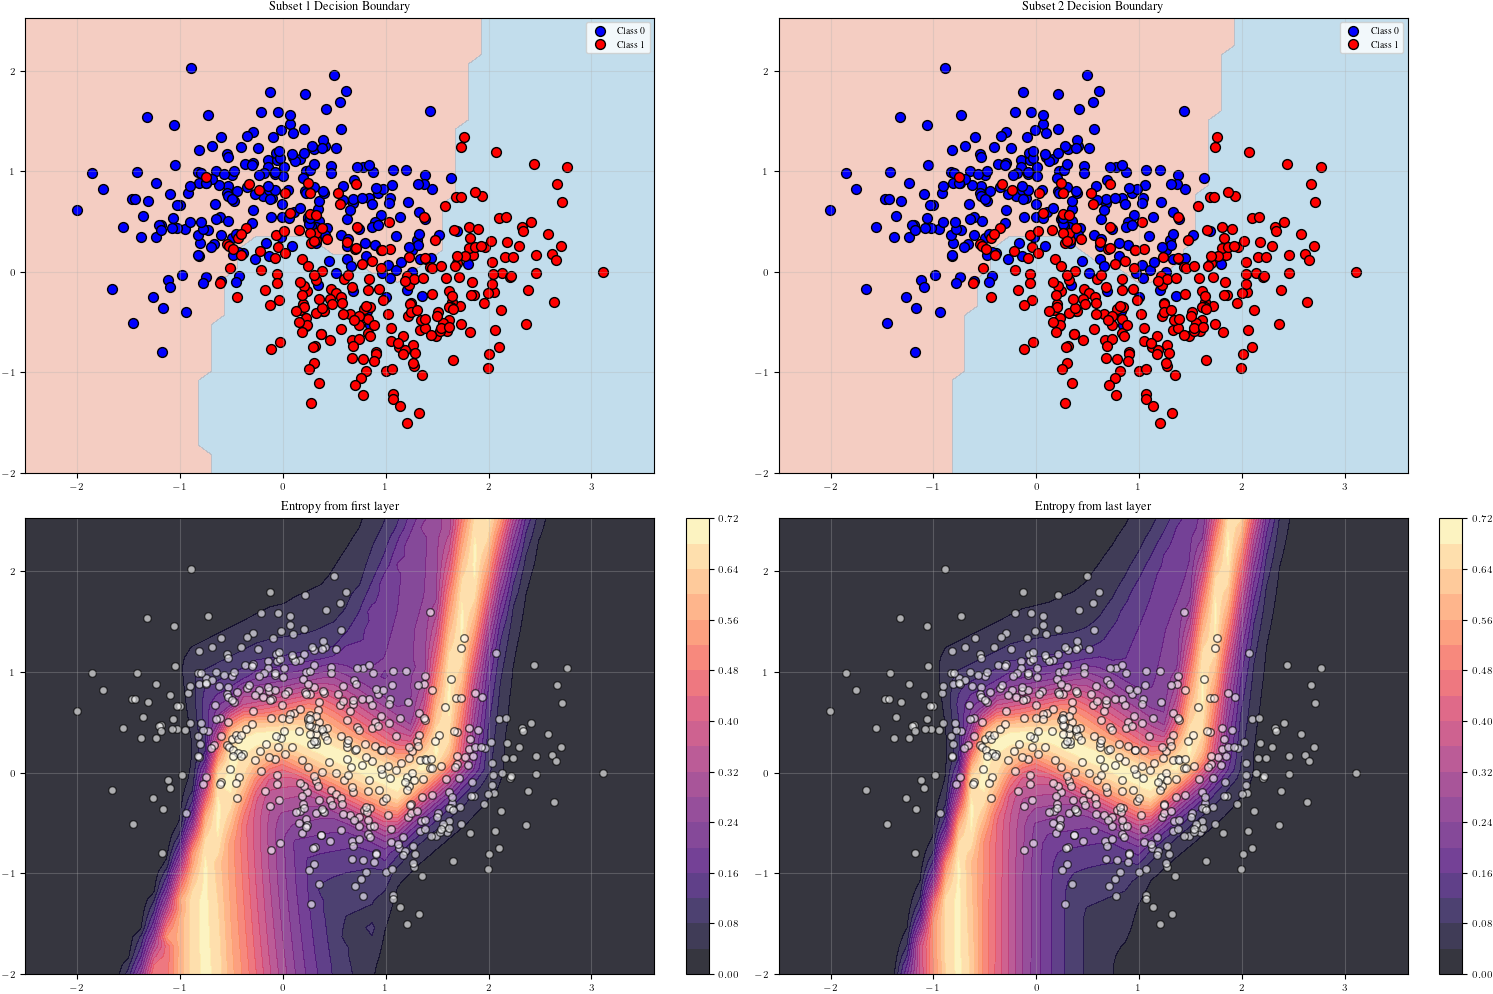

In [80]:
# Prepare data for plotting
predictive_class_s1 = predictive_probs_s1.argmax(dim=-1).cpu().numpy().reshape(xx.shape)
predictive_class_s2 = predictive_probs_s2.argmax(dim=-1).cpu().numpy().reshape(xx.shape)

predictive_entropy_s1_2d = predictive_entropy_s1.detach().cpu().numpy().reshape(xx.shape)
predictive_entropy_s2_2d = predictive_entropy_s2.detach().cpu().numpy().reshape(xx.shape)
fig, axs = plt.subplots(2, 2, figsize=(15,10))

# Decision Boundary s1
axs[0, 0].contourf(xx, yy, predictive_class_s1, alpha=0.4, levels=1, cmap='RdBu')
axs[0, 0].scatter(
    X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', edgecolors='k', s=50
)
axs[0, 0].scatter(
    X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', edgecolors='k', s=50
)
axs[0, 0].set_title('Subset 1 Decision Boundary')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# Decision Boundary s2
axs[0, 1].contourf(xx, yy, predictive_class_s2, alpha=0.4, levels=1, cmap='RdBu')
axs[0, 1].scatter(
    X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', edgecolors='k', s=50
)
axs[0, 1].scatter(
    X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', edgecolors='k', s=50
)
axs[0, 1].set_title('Subset 2 Decision Boundary')
axs[0, 1].legend()
axs[0, 1].grid(True, alpha=0.3)

# First Layer Uncertainty
cf3 = axs[1,0].contourf(
    xx, yy, predictive_entropy_s1_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[1,0].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1,0].set_title('Entropy from first layer')
axs[1,0].grid(True, alpha=0.3)
plt.colorbar(cf3, ax=axs[1,0])

# Last Layer Uncertainty
cf2 = axs[1,1].contourf(
    xx, yy, predictive_entropy_s2_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[1,1].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1,1].set_title('Entropy from last layer')
axs[1,1].grid(True, alpha=0.3)
plt.colorbar(cf2, ax=axs[1,1])

plt.savefig("nb_subset_decision_boundaries.pdf")
plt.show()

In [81]:
# Calculate aleatoric and epistemic uncertainty for subset 1
sampled_log_probs_s1 = torch.log(sampled_probs_s1 + 1e-10)
aleatoric_entropy_s1 = -torch.sum(sampled_probs_s1 * sampled_log_probs_s1, dim=-1)
mean_aleatoric_entropy_s1 = aleatoric_entropy_s1.mean(dim=0)  # [N]
print(f"Subset 1:\nAleatoric entropy: shape = {mean_aleatoric_entropy_s1.shape}")
epistemic_entropy_s1 = predictive_entropy_s1 - mean_aleatoric_entropy_s1
print(f"Epistemic entropy: shape = {epistemic_entropy_s1.shape}")

# Calculate aleatoric and epistemic uncertainty for subset 2
sampled_log_probs_s2 = torch.log(sampled_probs_s2 + 1e-10)
aleatoric_entropy_s2 = -torch.sum(sampled_probs_s2 * sampled_log_probs_s2, dim=-1)
mean_aleatoric_entropy_s2 = aleatoric_entropy_s2.mean(dim=0)  # [N]
print(f"Subset 2:\nAleatoric entropy: shape = {mean_aleatoric_entropy_s2.shape}")
epistemic_entropy_s2 = predictive_entropy_s2 - mean_aleatoric_entropy_s2
print(f"Epistemic entropy: shape = {epistemic_entropy_s2.shape}")

Subset 1:
Aleatoric entropy: shape = torch.Size([2500])
Epistemic entropy: shape = torch.Size([2500])
Subset 2:
Aleatoric entropy: shape = torch.Size([2500])
Epistemic entropy: shape = torch.Size([2500])


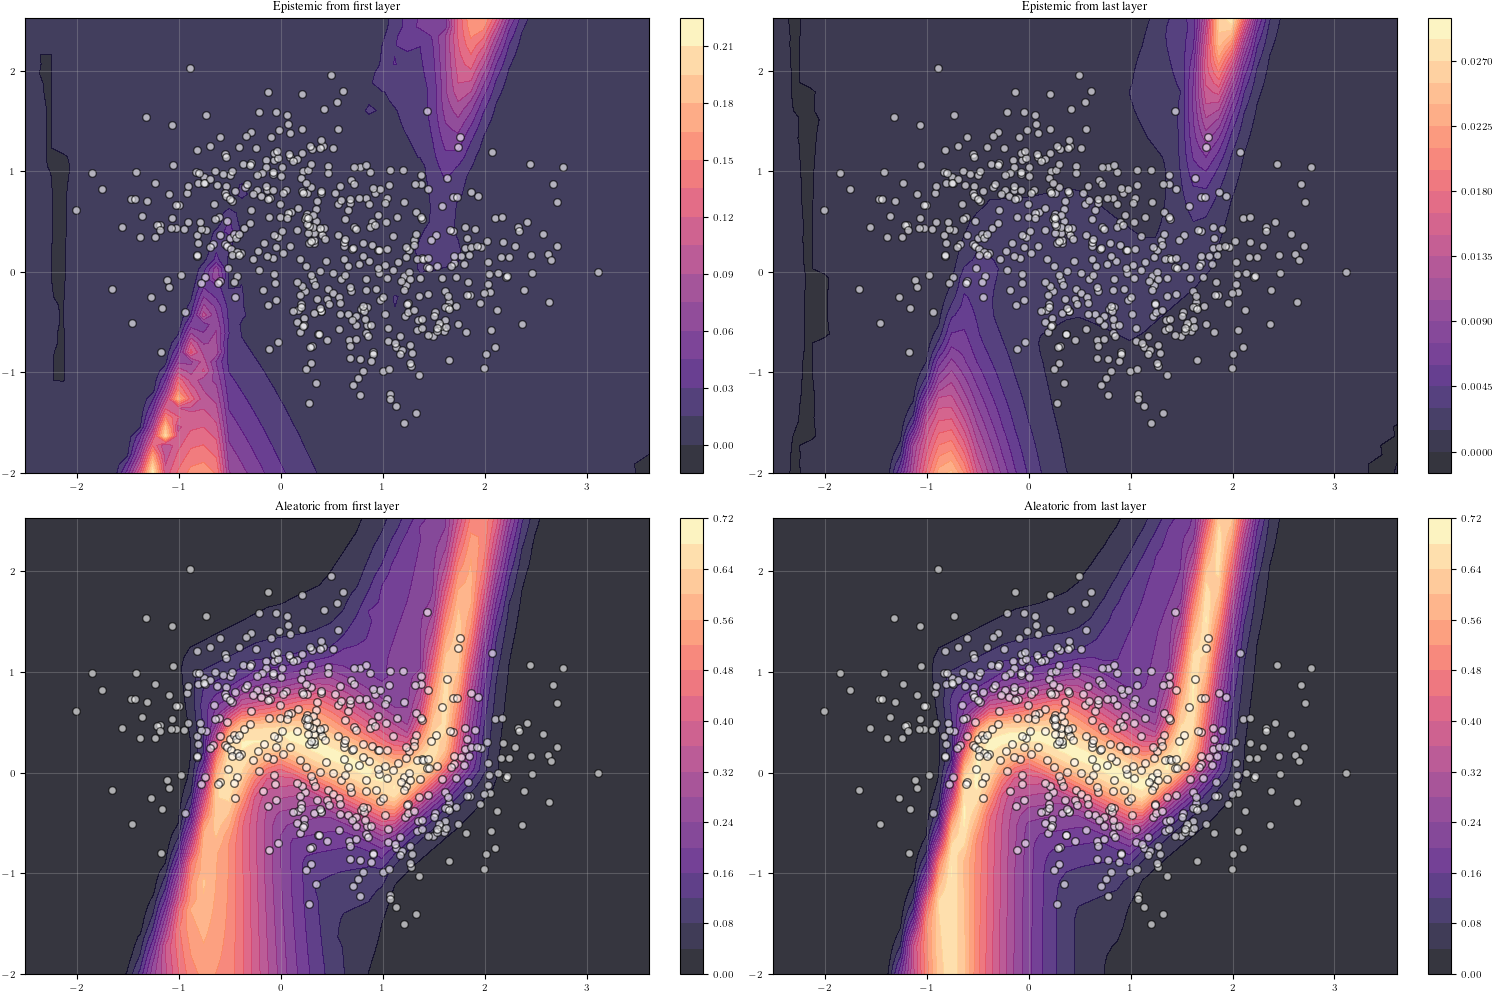

In [82]:
# Plot Aleatoric entropy from both subsets
epistemic_s1_2d = epistemic_entropy_s1.detach().cpu().numpy().reshape(xx.shape)
epistemic_s2_2d = epistemic_entropy_s2.detach().cpu().numpy().reshape(xx.shape)
aleatoric_s1_2d = mean_aleatoric_entropy_s1.detach().cpu().numpy().reshape(xx.shape)
aleatoric_s2_2d = mean_aleatoric_entropy_s2.detach().cpu().numpy().reshape(xx.shape)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Plot Epistemic entropy from first subset
cf1 = axs[0,0].contourf(
    xx, yy, epistemic_s1_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[0,0].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[0,0].set_title('Epistemic from first layer')
axs[0,0].grid(True, alpha=0.3)
plt.colorbar(cf1, ax=axs[0,0])

# Plot Epistemic entropy from second subset
cf2 = axs[0,1].contourf(
    xx, yy, epistemic_s2_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[0,1].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[0,1].set_title('Epistemic from last layer')
axs[0,1].grid(True, alpha=0.3)
plt.colorbar(cf2, ax=axs[0,1])

# Plot Aleatoric entropy from first subset
cf3 = axs[1,0].contourf(
    xx, yy, aleatoric_s1_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[1,0].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1,0].set_title('Aleatoric from first layer')
axs[1,0].grid(True, alpha=0.3)
plt.colorbar(cf3, ax=axs[1,0])

# Plot Aleatoric entropy from second subset
cf4 = axs[1,1].contourf(
    xx, yy, aleatoric_s2_2d, alpha=0.8, levels=20, cmap='magma'
)
axs[1,1].scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1,1].set_title('Aleatoric from last layer')
axs[1,1].grid(True, alpha=0.3)
plt.colorbar(cf4, ax=axs[1,1])
plt.savefig("nb_epi_vs_ale_subsets.pdf")
plt.show()

Spearman correlation epi first layer - aleatoric last: 0.950, p-value: 0.000e+00
Spearman correlation epi last layer - aleatoric first: 0.984, p-value: 0.000e+00


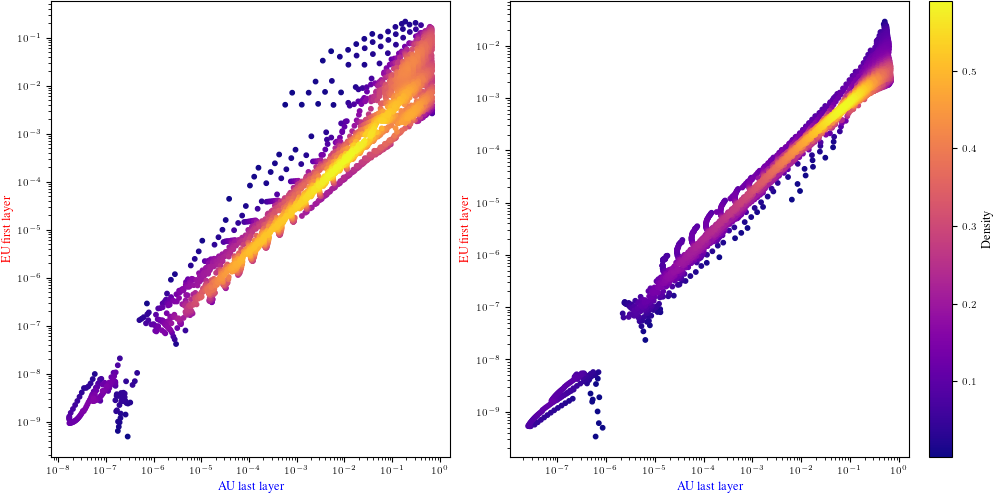

In [83]:
# Plot correlation aleatoric from last layer vs epistemic uncertainty from first layer
ax1_aleatoric_s2 = mean_aleatoric_entropy_s2.detach().cpu().numpy()
ax2_epistemic_s1 = epistemic_entropy_s1.detach().cpu().numpy()

correlation_1, p_value_1 = stats.spearmanr(ax1_aleatoric_s2, ax2_epistemic_s1)

print(f"Spearman correlation epi first layer - aleatoric last: {correlation_1:.3f}, p-value: {p_value_1:.3e}") 

# Filter out zero or negative values for log-log plot
mask = (ax1_aleatoric_s2 > 0) & (ax2_epistemic_s1 > 0)
ax1_aleatoric_s2, ax2_epistemic_s1 = ax1_aleatoric_s2[mask], ax2_epistemic_s1[mask]

# Density estimation (for color)
xy = np.vstack([np.log10(ax1_aleatoric_s2), np.log10(ax2_epistemic_s1)])
z = gaussian_kde(xy)(xy)

# Sort by density (so dense points are on top)
idx = z.argsort()
ax1_aleatoric_s2, ax2_epistemic_s1, z = ax1_aleatoric_s2[idx], ax2_epistemic_s1[idx], z[idx]

# plot2 correlation aleatoric from first layer vs epistemic uncertainty from last layer
ax3_aleatoric_s1 = mean_aleatoric_entropy_s1.detach().cpu().numpy()
ax4_epistemic_s2 = epistemic_entropy_s2.detach().cpu().numpy()

correlation_2, p_value_2 = stats.spearmanr(ax3_aleatoric_s1, ax4_epistemic_s2)

mask2 = (ax3_aleatoric_s1 > 0) & (ax4_epistemic_s2 > 0)
ax3_aleatoric_s1, ax4_epistemic_s2 = ax3_aleatoric_s1[mask2], ax4_epistemic_s2[mask2]

print(f"Spearman correlation epi last layer - aleatoric first: {correlation_2:.3f}, p-value: {p_value_2:.3e}") 

# Density estimation (for color)
st = np.vstack([np.log10(ax3_aleatoric_s1), np.log10(ax4_epistemic_s2)])
k = gaussian_kde(st)(st)

# Sort by density (so dense points are on top)
ids = k.argsort()
ax3_aleatoric_s1, ax4_epistemic_s2, k = ax3_aleatoric_s1[ids], ax4_epistemic_s2[ids], k[ids]

# Visualize rank correlation 
fig, axs = plt.subplots(1, 2, figsize=(10,5))

cf1 = axs[0].scatter(ax1_aleatoric_s2, ax2_epistemic_s1, c=z, s=10, cmap="plasma")
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlabel("AU last layer", color="blue")
axs[0].set_ylabel("EU first layer", color="red")
#plt.colorbar(cf1, ax=axs[0], label="Density")

cf2 = axs[1].scatter(ax3_aleatoric_s1, ax4_epistemic_s2, c=k, s=10, cmap="plasma")
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlabel("AU last layer", color="blue")
axs[1].set_ylabel("EU first layer", color="red")
plt.colorbar(cf2, ax=axs[1], label="Density")

plt.savefig("nb_rank_correlation.pdf")
plt.show()


## 12. Create Validation/OOD Dataset

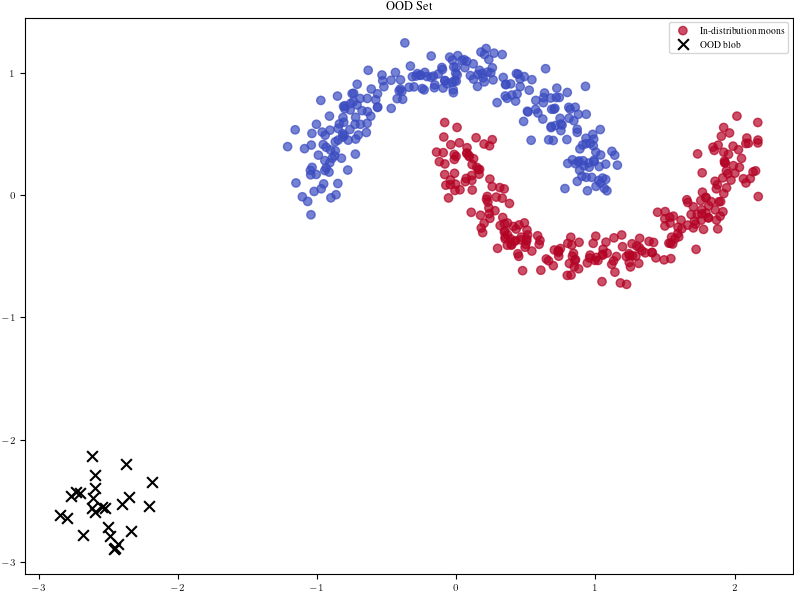

Dataset size: 525
Input dimension: 2
In-distribution classes present: [0, 1]
OOD samples: 25


In [125]:
from sklearn.datasets import make_blobs

# Create an OOD probe dataset: in-distribution moons plus an unlabeled blob
X_val, y_val = make_moons(n_samples=500, noise=0.1, random_state=42)

def transform_dataset(X, shift=(0.5, 0.5), scale=0.5):
    X_transformed = X * scale + np.array(shift)
    return X_transformed

# Generate a separate blob outside the training distribution
X_blob, _ = make_blobs(n_samples=25, centers=[[-2.5, -2.5]], cluster_std=0.2, random_state=42)


# Combine inputs, the blob marked as OOD
X_cluster = np.vstack([X_val, X_blob])
y_cluster = np.hstack([y_val, np.full(len(X_blob), -1, dtype=np.int64)])
is_ood = y_cluster == -1

# Convert to torch tensors. y_valTensor is for analysis only: -1 marks OOD blob points.
X_valTensor = torch.tensor(X_cluster, dtype=torch.float32)
y_valTensor = torch.tensor(y_cluster, dtype=torch.long)

# Create DataLoader for analysis / visualization.
ood_dataset = TensorDataset(X_valTensor, y_valTensor)
ood_loader = DataLoader(ood_dataset, batch_size=32, shuffle=False)
ood_full_loader = DataLoader(ood_dataset, batch_size=len(ood_dataset), shuffle=False)

# Visualize dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_cluster[~is_ood, 0], X_cluster[~is_ood, 1], c=y_cluster[~is_ood], cmap='coolwarm', alpha=0.7, label='In-distribution moons')
plt.scatter(X_cluster[is_ood, 0], X_cluster[is_ood, 1], c='black', marker='x', s=60, label='OOD blob')
plt.title("OOD Set")
plt.legend()
plt.savefig("oodSet.pdf")
plt.show()

print(f"Dataset size: {len(X_valTensor)}")
print(f"Input dimension: {X_valTensor.shape[1]}")
print(f"In-distribution classes present: {sorted(np.unique(y_val).tolist())}")
print(f"OOD samples: {int(is_ood.sum())}")

In [126]:
# validate for analysis
model.eval()
with torch.no_grad():
    logits_ood = model(X_valTensor.to(device))
    vali_probs = F.softmax(logits_ood, dim=1)
    entropy_values = -torch.sum(vali_probs * torch.log(vali_probs + 1e-10), dim=1)

print("min:", entropy_values.min().item())
print("max:", entropy_values.max().item())
print("mean:", entropy_values.mean().item())

min: 2.412053223821431e-09
max: 0.693098247051239
mean: 0.25878894329071045


### Computing Entropy on OOD data


In [127]:
# Prepare ood inputs (use a grid for visualization)
x_min, x_max = X_cluster[:, 0].min() - 0.5, X_cluster[:, 0].max() + 0.5
y_min, y_max = X_cluster[:, 1].min() - 0.5, X_cluster[:, 1].max() + 0.5
xx_ood, yy_ood = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))
X_ood_grid = torch.tensor(np.c_[xx_ood.ravel(), yy_ood.ravel()], dtype=torch.float32, device=device)

print(f"OOD grid: {X_ood_grid.shape}")

OOD grid: torch.Size([2500, 2])


In [128]:
# MAP predictions
with torch.no_grad():
    base_logits_ood = model(X_ood_grid)

# First layer
# Generate perturbations for subset 1
v_samples_s1_ood = torch.randn(n_params_s1, n_posterior_samples, device=device, dtype=torch.float32)
perturbations_s1_ood = low_rank_scale_op_s1 @ v_samples_s1_ood
perturbations_s1_ood_full = torch.zeros(P, n_posterior_samples, device=device)
perturbations_s1_ood_full[s1_mask, :] = perturbations_s1_ood

# Compute JVP for OOD samples (first layer)
print("Computing JVP for first layer on OOD...")
jvp_results_s1_ood = []
for i in tqdm(range(n_samples_predict), desc="First Layer OOD JVPs"):
    tangent = perturbations_s1_ood_full[:, i]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_ood_grid, tangent)
    jvp_results_s1_ood.append(jvp_output)

jvp_results_s1_ood = torch.stack(jvp_results_s1_ood, dim=0)  # [n_samples, N, C]

# Compute sampled logits and probabilities
sampled_logits_s1_ood = base_logits_ood.unsqueeze(0) + jvp_results_s1_ood
sampled_probs_s1_ood = F.softmax(sampled_logits_s1_ood, dim=-1)

# Predictive probabilities (average across samples)
predictive_probs_s1_ood = sampled_probs_s1_ood.mean(dim=0).detach()

# Entropy for each sample
sampled_log_probs_s1_ood = torch.log(sampled_probs_s1_ood + 1e-10)
aleatoric_entropy_s1_ood = -torch.sum(sampled_probs_s1_ood * sampled_log_probs_s1_ood, dim=-1)

# Expected entropy (aleatoric)
mean_aleatoric_entropy_s1_ood = aleatoric_entropy_s1_ood.mean(dim=0)

# Predictive entropy
log_probs_s1_ood = torch.log(predictive_probs_s1_ood + 1e-10)
predictive_entropy_s1_ood = -torch.sum(predictive_probs_s1_ood * log_probs_s1_ood, dim=-1)

# Mutual information (epistemic)
epistemic_entropy_s1_ood = predictive_entropy_s1_ood - mean_aleatoric_entropy_s1_ood

print(epistemic_entropy_s1_ood.shape)


Computing JVP for first layer on OOD...


First Layer OOD JVPs:   0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([2500])


In [129]:
# Generate perturbations for subset 2
v_samples_s2_ood = torch.randn(n_params_s2, n_posterior_samples, device=device, dtype=torch.float32)
perturbations_s2_ood = low_rank_scale_op_s2 @ v_samples_s2_ood
perturbations_s2_ood_full = torch.zeros(P, n_posterior_samples, device=device)
perturbations_s2_ood_full[s2_mask, :] = perturbations_s2_ood

# Compute JVP for OOD samples (last layer)
print("Computing JVP for last layer on OOD...")
jvp_results_s2_ood = []
for i in tqdm(range(n_samples_predict), desc="Last Layer OOD JVPs"):
    tangent = perturbations_s2_ood_full[:, i]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_ood_grid, tangent)
    jvp_results_s2_ood.append(jvp_output)

jvp_results_s2_ood = torch.stack(jvp_results_s2_ood, dim=0)  
# [n_posterior_samples, N, C]

# Compute sampled logits and probabilities
sampled_logits_s2_ood = base_logits_ood.unsqueeze(0) + jvp_results_s2_ood
sampled_probs_s2_ood = F.softmax(sampled_logits_s2_ood, dim=-1)

# Predictive probabilities (average across samples)
predictive_probs_s2_ood = sampled_probs_s2_ood.mean(dim=0).detach()

# Entropy for each sample
sampled_log_probs_s2_ood = torch.log(sampled_probs_s2_ood + 1e-10)
aleatoric_entropy_s2_ood = -torch.sum(sampled_probs_s2_ood * sampled_log_probs_s2_ood, dim=-1)

# Expected entropy (aleatoric)
mean_aleatoric_entropy_s2_ood = aleatoric_entropy_s2_ood.mean(dim=0)
print(mean_aleatoric_entropy_s2_ood.shape)

# Predictive entropy
log_probs_s2_ood = torch.log(predictive_probs_s2_ood + 1e-10)
predictive_entropy_s2_ood = -torch.sum(predictive_probs_s2_ood * log_probs_s2_ood, dim=-1)

# Mutual information (epistemic)
epistemic_entropy_s2_ood = predictive_entropy_s2_ood - mean_aleatoric_entropy_s2_ood
print(epistemic_entropy_s2_ood.shape)

Computing JVP for last layer on OOD...


Last Layer OOD JVPs:   0%|          | 0/100 [00:00<?, ?it/s]

torch.Size([2500])
torch.Size([2500])


In [130]:
print(f"Number of visualization grid points: {X_ood_grid.shape[0]}")
print(f"Number of labeled probe samples: {X_valTensor.shape[0]}")
print(f"Number of OOD probe samples: {int((y_valTensor == -1).sum())}")

Number of visualization grid points: 2500
Number of labeled probe samples: 525
Number of OOD probe samples: 25


Spearman correlation: 0.917, p-value: 0.000e+00


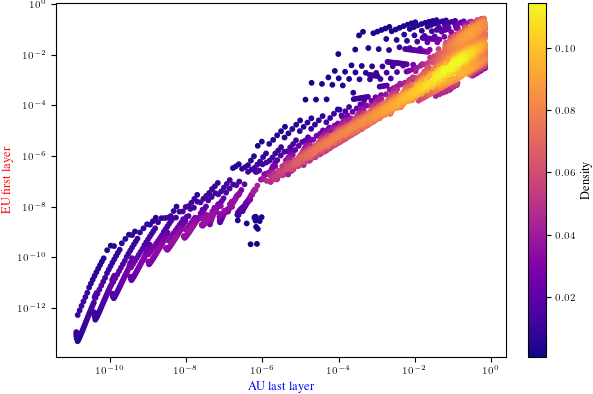

In [131]:
# Plot Entropy vs Mutual Information for OOD data
ale_ood = mean_aleatoric_entropy_s2_ood.detach().cpu().numpy()
epi_ood = epistemic_entropy_s1_ood.detach().cpu().numpy()

correlation_ood, p_value_ood = stats.spearmanr(ale_ood, epi_ood)

print(f"Spearman correlation: {correlation_ood:.3f}, p-value: {p_value_ood:.3e}") 

# Filter out zero or negative values for log-log plot
mask = (ale_ood > 0) & (epi_ood > 0)
ale_ood, epi_ood = ale_ood[mask], epi_ood[mask]

# Density estimation (for color)
xy = np.vstack([np.log10(ale_ood), np.log10(epi_ood)])
z = gaussian_kde(xy)(xy)

# Sort by density (so dense points are on top)
idx = z.argsort()
ale_ood, epi_ood, z = ale_ood[idx], epi_ood[idx], z[idx]

plt.figure(figsize=(6, 4))
plt.scatter(ale_ood, epi_ood, c=z, s=10, cmap="plasma")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("AU last layer", color="blue")
plt.ylabel("EU first layer", color="red")

plt.colorbar(label="Density")
plt.savefig("nb_correlation_ood_epi1_ale2.pdf")
plt.show()

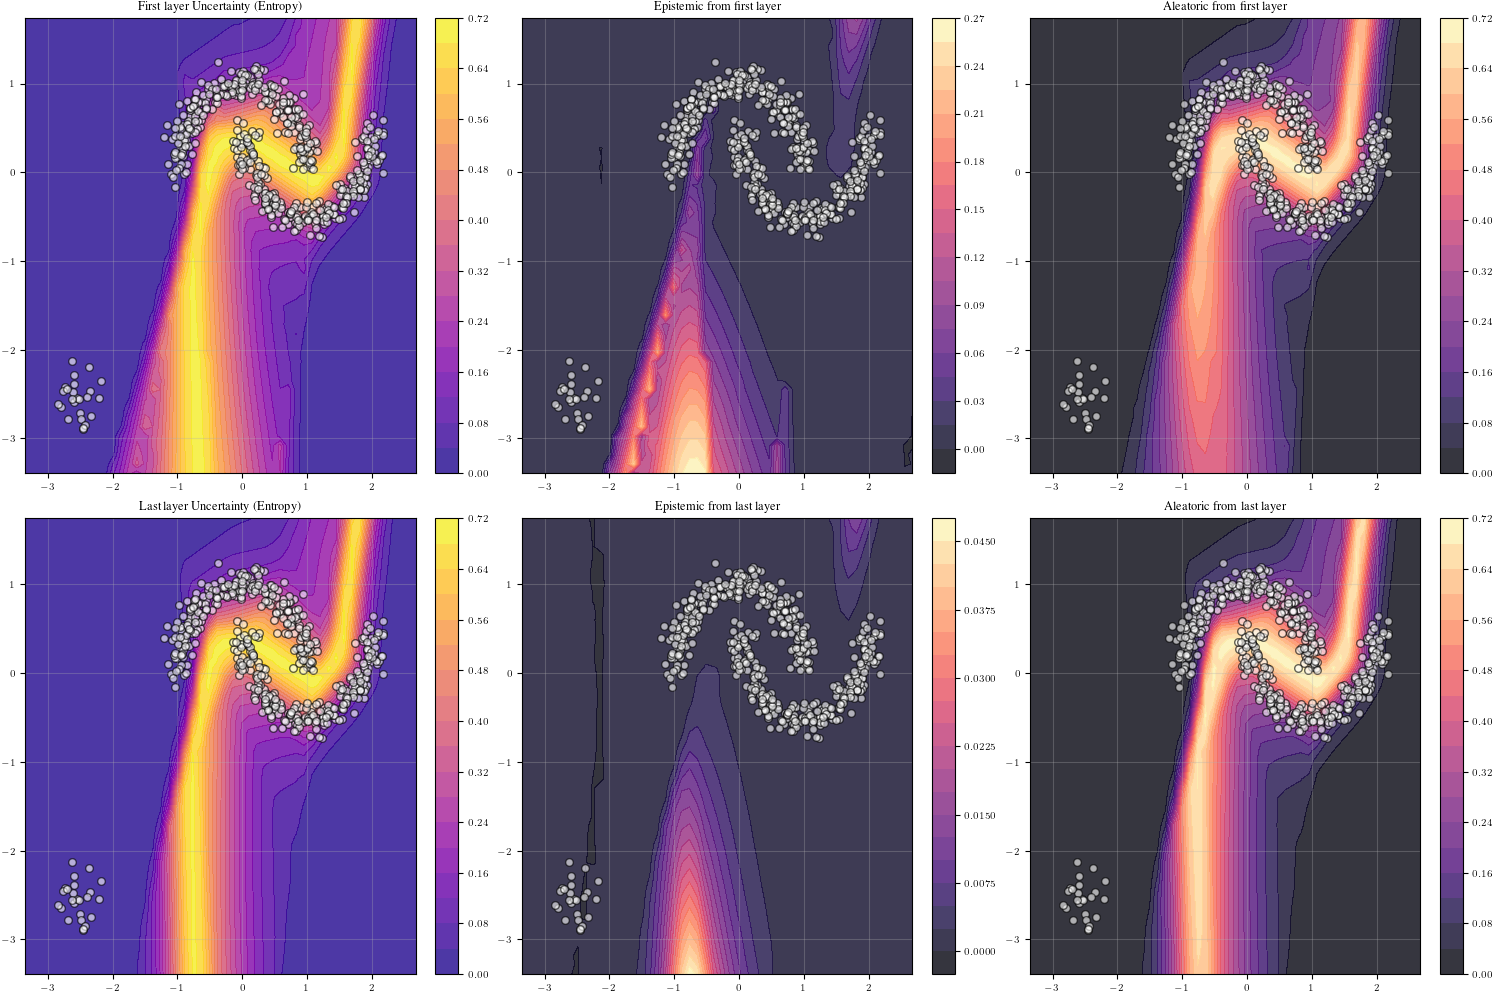

In [132]:
# Plot entropy
predictive_entropy_s1_ood_2d = predictive_entropy_s1_ood.cpu().numpy().reshape(xx_ood.shape)
predictive_entropy_s2_ood_2d = predictive_entropy_s2_ood.cpu().numpy().reshape(xx_ood.shape)
epi_ood_2d_s2 = epistemic_entropy_s2_ood.detach().cpu().numpy().reshape(xx_ood.shape)
ale_ood_2d_s2 = mean_aleatoric_entropy_s2_ood.detach().cpu().numpy().reshape(xx_ood.shape)
epi_ood_2d_s1 = epistemic_entropy_s1_ood.detach().cpu().numpy().reshape(xx_ood.shape)
ale_ood_2d_s1 = mean_aleatoric_entropy_s1_ood.detach().cpu().numpy().reshape(xx_ood.shape)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Plot Epistemic entropy from first subset
cf1 = axs[0, 1].contourf(
    xx_ood, yy_ood, epi_ood_2d_s1, alpha=0.8, levels=20, cmap='magma'
)
axs[0, 1].scatter(X_cluster[:, 0], X_cluster[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[0, 1].set_title('Epistemic from first layer')
axs[0, 1].grid(True, alpha=0.3)
plt.colorbar(cf1, ax=axs[0,1])

# Plot Aleatoric entropy from first subset
cf2 = axs[0,2].contourf(
    xx_ood, yy_ood, ale_ood_2d_s1, alpha=0.8, levels=20, cmap='magma'
)
axs[0, 2].scatter(X_cluster[:, 0], X_cluster[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[0, 2].set_title('Aleatoric from first layer')
axs[0, 2].grid(True, alpha=0.3)
plt.colorbar(cf2, ax=axs[0, 2])

cf3 = axs[0, 0].contourf(
    xx_ood, yy_ood, predictive_entropy_s1_ood_2d, alpha=0.8, levels=20, cmap='plasma'
)
axs[0, 0].scatter(X_cluster[:, 0], X_cluster[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[0, 0].set_title('First layer Uncertainty (Entropy)')
axs[0, 0].grid(True, alpha=0.3)
plt.colorbar(cf3, ax=axs[0, 0])

# Plot Epistemic entropy from first subset
cf5 = axs[1, 1].contourf(
    xx_ood, yy_ood, epi_ood_2d_s2, alpha=0.8, levels=20, cmap='magma'
)
axs[1, 1].scatter(X_cluster[:, 0], X_cluster[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1, 1].set_title('Epistemic from last layer')
axs[1, 1].grid(True, alpha=0.3)
plt.colorbar(cf5, ax=axs[1,1])

# Plot Aleatoric entropy from second subset
cf6 = axs[1,2].contourf(
    xx_ood, yy_ood, ale_ood_2d_s2, alpha=0.8, levels=20, cmap='magma'
)
axs[1, 2].scatter(X_cluster[:, 0], X_cluster[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1, 2].set_title('Aleatoric from last layer')
axs[1, 2].grid(True, alpha=0.3)
plt.colorbar(cf6, ax=axs[1, 2])

cf4 = axs[1, 0].contourf(
    xx_ood, yy_ood, predictive_entropy_s2_ood_2d, alpha=0.8, levels=20, cmap='plasma'
)
axs[1, 0].scatter(X_cluster[:, 0], X_cluster[:, 1], c='white', edgecolors='k', s=30, alpha=0.6)
axs[1, 0].set_title('Last layer Uncertainty (Entropy)')
axs[1, 0].grid(True, alpha=0.3)
plt.colorbar(cf4, ax=axs[1, 0])

plt.savefig("nb_entropy_ood.pdf")
plt.show()

## First layer aleatoric, last layer epistemic

Spearman correlation: 0.965, p-value: 0.000e+00


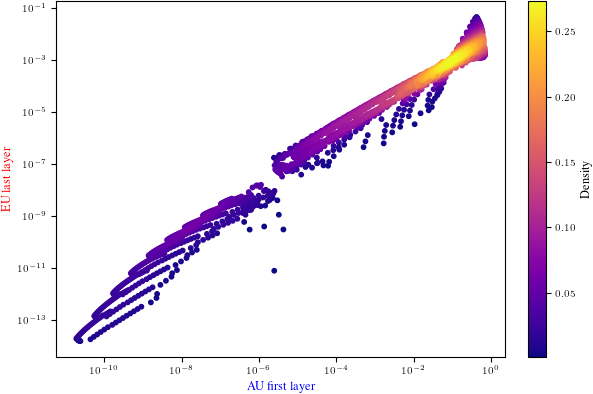

In [133]:
#Spearman correlation 
ale1_ood = mean_aleatoric_entropy_s1_ood.detach().cpu().numpy()
epi2_ood = epistemic_entropy_s2_ood.detach().cpu().numpy()

correlation_ood, p_value_ood = stats.spearmanr(ale1_ood, epi2_ood)

print(f"Spearman correlation: {correlation_ood:.3f}, p-value: {p_value_ood:.3e}") 

# Filter out zero or negative values for log-log plot
mask = (ale1_ood > 0) & (epi2_ood > 0)
ale1_ood, epi2_ood = ale1_ood[mask], epi2_ood[mask]

# Density estimation (for color)
xy = np.vstack([np.log10(ale1_ood), np.log10(epi2_ood)])
z = gaussian_kde(xy)(xy)

# Sort by density (so dense points are on top)
idx = z.argsort()
ale1_ood, epi2_ood, z = ale1_ood[idx], epi2_ood[idx], z[idx]

plt.figure(figsize=(6, 4))
plt.scatter(ale1_ood, epi2_ood, c=z, s=10, cmap="plasma")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("AU first layer", color="blue")
plt.ylabel("EU last layer", color="red")

plt.colorbar(label="Density")
plt.savefig("nb_correlation_ood_epi2_ale1.pdf")
plt.show()

### AUROC bar chart for epistemic uncertainty

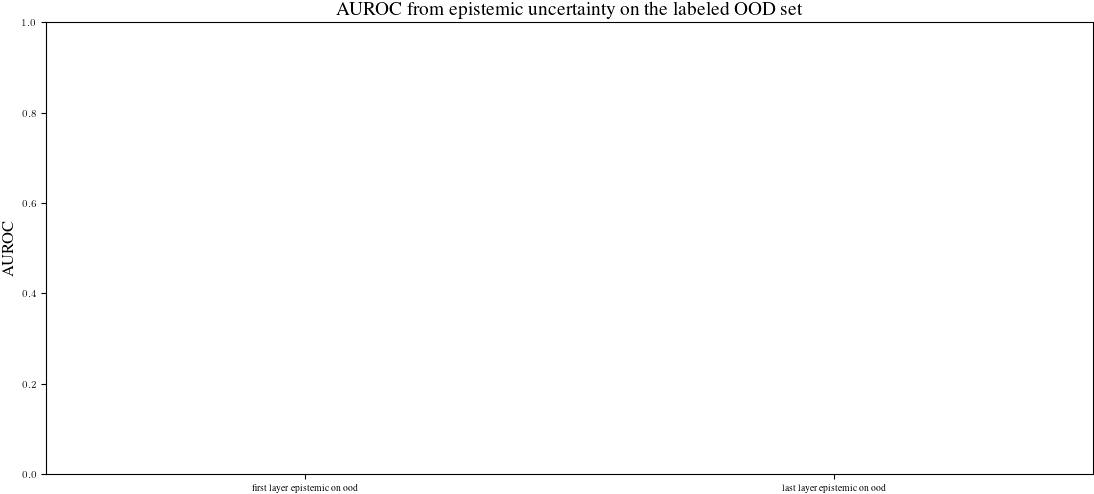

First subset epistemic AUROC: 0.000
Second subset epistemic AUROC: 0.000


In [134]:
from untangle.utils import auroc

# Binary probe targets: 1 for OOD, 0 for in-distribution
probe_targets = (y_valTensor == -1).int().to(device)

# Compute epistemic uncertainty for the labeled probe set using the same linearized JVP sampling
# First subset (s1)
with torch.no_grad():
    base_logits_val = model(X_valTensor.to(device))

v_samples_s1_val = torch.randn(n_params_s1, n_posterior_samples, device=device, dtype=torch.float32)
perturbations_s1_val = low_rank_scale_op_s1 @ v_samples_s1_val
perturbations_s1_val_full = torch.zeros(P, n_posterior_samples, device=device)
perturbations_s1_val_full[s1_mask, :] = perturbations_s1_val

jvp_results_s1_val = []
for i in range(n_samples_predict):
    tangent = perturbations_s1_val_full[:, i]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_valTensor.to(device), tangent)
    jvp_results_s1_val.append(jvp_output)
jvp_results_s1_val = torch.stack(jvp_results_s1_val, dim=0)

sampled_logits_s1_val = base_logits_val.unsqueeze(0) + jvp_results_s1_val
sampled_probs_s1_val = F.softmax(sampled_logits_s1_val, dim=-1)
predictive_probs_s1_val = sampled_probs_s1_val.mean(dim=0).detach()
sampled_log_probs_s1_val = torch.log(sampled_probs_s1_val + 1e-10)
aleatoric_entropy_s1_val = -torch.sum(sampled_probs_s1_val * sampled_log_probs_s1_val, dim=-1)
mean_aleatoric_entropy_s1_val = aleatoric_entropy_s1_val.mean(dim=0)
log_probs_s1_val = torch.log(predictive_probs_s1_val + 1e-10)
predictive_entropy_s1_val = -torch.sum(predictive_probs_s1_val * log_probs_s1_val, dim=-1)
epistemic_entropy_s1_val = predictive_entropy_s1_val - mean_aleatoric_entropy_s1_val

# Second subset (s2)
with torch.no_grad():
    base_logits_val = model(X_valTensor.to(device))

v_samples_s2_val = torch.randn(n_params_s2, n_posterior_samples, device=device, dtype=torch.float32)
perturbations_s2_val = low_rank_scale_op_s2 @ v_samples_s2_val
perturbations_s2_val_full = torch.zeros(P, n_posterior_samples, device=device)
perturbations_s2_val_full[s2_mask, :] = perturbations_s2_val

jvp_results_s2_val = []
for i in range(n_samples_predict):
    tangent = perturbations_s2_val_full[:, i]
    jvp_output = compute_jvp_single(model, params_dict, param_keys, X_valTensor.to(device), tangent)
    jvp_results_s2_val.append(jvp_output)
jvp_results_s2_val = torch.stack(jvp_results_s2_val, dim=0)

sampled_logits_s2_val = base_logits_val.unsqueeze(0) + jvp_results_s2_val
sampled_probs_s2_val = F.softmax(sampled_logits_s2_val, dim=-1)
predictive_probs_s2_val = sampled_probs_s2_val.mean(dim=0).detach()
sampled_log_probs_s2_val = torch.log(sampled_probs_s2_val + 1e-10)
aleatoric_entropy_s2_val = -torch.sum(sampled_probs_s2_val * sampled_log_probs_s2_val, dim=-1)
mean_aleatoric_entropy_s2_val = aleatoric_entropy_s2_val.mean(dim=0)
log_probs_s2_val = torch.log(predictive_probs_s2_val + 1e-10)
predictive_entropy_s2_val = -torch.sum(predictive_probs_s2_val * log_probs_s2_val, dim=-1)
epistemic_entropy_s2_val = predictive_entropy_s2_val - mean_aleatoric_entropy_s2_val

# Compute AUROC (higher epistemic score -> more likely OOD)
auroc_first_subset = auroc(probe_targets.float(), epistemic_entropy_s1_val)
auroc_second_subset = auroc(probe_targets.float(), epistemic_entropy_s2_val)

labels = [
    "first layer epistemic on ood",
    "last layer epistemic on ood",
]

values = [auroc_first_subset.item() if torch.is_tensor(auroc_first_subset) else auroc_first_subset,
          auroc_second_subset.item() if torch.is_tensor(auroc_second_subset) else auroc_second_subset]

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, values, color=["#4C78A8", "#E45756"])

plt.ylim(0.0, 1.0)
plt.ylabel("AUROC", fontsize=12)
plt.title("AUROC from epistemic uncertainty on the labeled OOD set", fontsize=14)

plt.savefig("nb_ood_epistemic_auroc_bar_chart.pdf")
plt.show()

print(f"First subset epistemic AUROC: {values[0]:.3f}")
print(f"Second subset epistemic AUROC: {values[1]:.3f}")

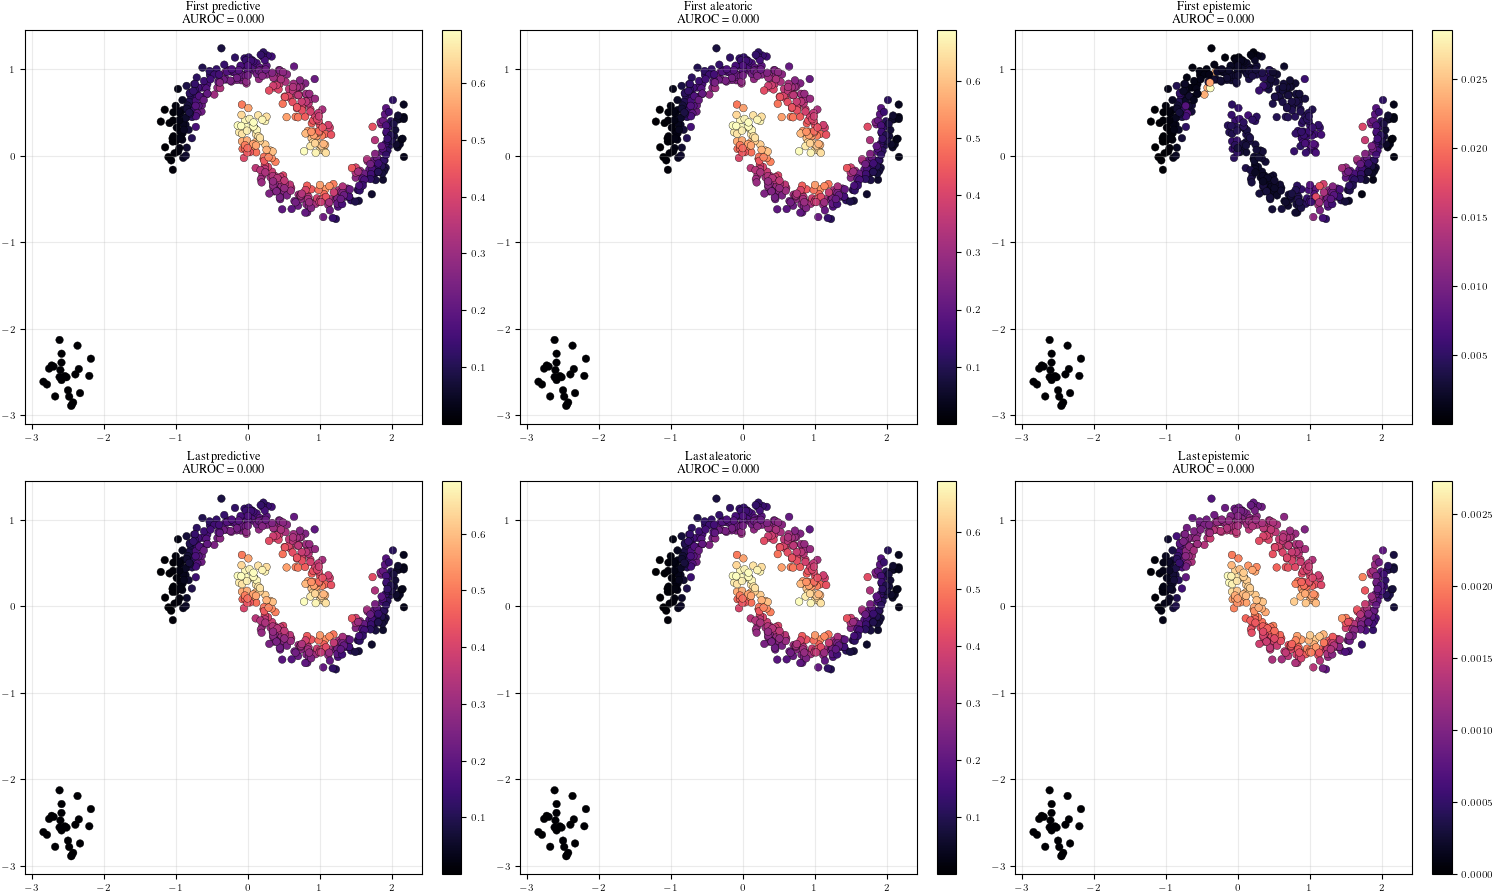

In [135]:
plots = [
    ("First predictive", predictive_entropy_s1_val),
    ("First aleatoric", mean_aleatoric_entropy_s1_val),
    ("First epistemic", epistemic_entropy_s1_val),
    ("Last predictive", predictive_entropy_s2_val),
    ("Last aleatoric", mean_aleatoric_entropy_s2_val),
    ("Last epistemic", epistemic_entropy_s2_val),
]

is_ood_np = (y_valTensor.numpy() == -1)

fig, axs = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)

for ax, (title, values) in zip(axs.ravel(), plots):
    scores = values.detach().cpu().numpy()

    sc = ax.scatter(
        X_valTensor[:, 0],
        X_valTensor[:, 1],
        c=scores,
        cmap="magma",
        s=30,
        edgecolors="k",
        linewidths=0.25,
    )

    ax.scatter(
        X_valTensor[is_ood_np, 0],
        X_valTensor[is_ood_np, 1],
        facecolors="none",
        s=85,
        linewidths=1.4,
    )

    auc = auroc((y_valTensor == -1).int(), values.detach().cpu()).item()
    ax.set_title(f"{title}\nAUROC = {auc:.3f}")
    ax.grid(True, alpha=0.25)
    fig.colorbar(sc, ax=ax)

plt.savefig("nb_probe_uncertainty_ood_auc_points.pdf")
plt.show()
